### Notebook modelo de árbol de decisión y vecinos cercanos

En esta sesión nos concentraremos en la aplicación práctica de ambos modelos usando un pequeño conjunto de datos de habitabilidad de exoplanetas.

**Objetivos:**
- entrenar un **árbol de decisión** y un clasificador **kNN** con `scikit-learn`,
- interpretar predicciones y calcular `accuracy`,
- comparar ambos métodos en un mismo problema,
- entender por qué **kNN requiere escalamiento** de variables y los árboles no necesariamente.


(Adaptado de  Viviana Acquaviva (2023))



## Decision Trees

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


https://www.kaggle.com/code/willkoehrsen/visualize-a-decision-tree-w-python-scikit-learn

In [58]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd


In [59]:
font = {'size'   : 20}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=10)
matplotlib.rc('ytick', labelsize=10)
matplotlib.rcParams['figure.dpi'] = 300

In [60]:
#Paquetes para visualización

from io import StringIO
from IPython.display import Image
import pydotplus

from sklearn.tree import export_graphviz

### Subconjunto de base de datos de Habitabilidad de planetas https://phl.upr.edu/projects/habitable-exoplanets-catalog

In [61]:
LearningSet = pd.read_csv('HPLearningSet.csv', index_col=0)

**Variables:**
- `S_MASS`: masa estelar ($M_\odot$)
- `P_PERIOD`: período orbital (días)
- `P_DISTANCE`: distancia planeta–estrella (AU)
- `P_HABITABLE`: clase objetivo (0 = no habitable, 1 = habitable)


In [62]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


### Haga una revisión rápida del set de datos
- Encuentre el tamaño del dataset, y las categorías de la variable `P_HABITABLE` y los ejemplos en cada categoría.
- También visualice la relación entre la masa, el periodo y la habitabilidad del planeta. Grafique el periodo en escala log

In [63]:
# Tamaño del dataset
print(f"El dataset tiene {LearningSet.shape[0]} filas y {LearningSet.shape[1]} columnas.")

# Categorías de P_HABITABLE y conteo de ejemplos
print("\nDistribución de la variable objetivo (P_HABITABLE):")
print(LearningSet['P_HABITABLE'].value_counts())

El dataset tiene 18 filas y 5 columnas.

Distribución de la variable objetivo (P_HABITABLE):
P_HABITABLE
0    10
1     8
Name: count, dtype: int64


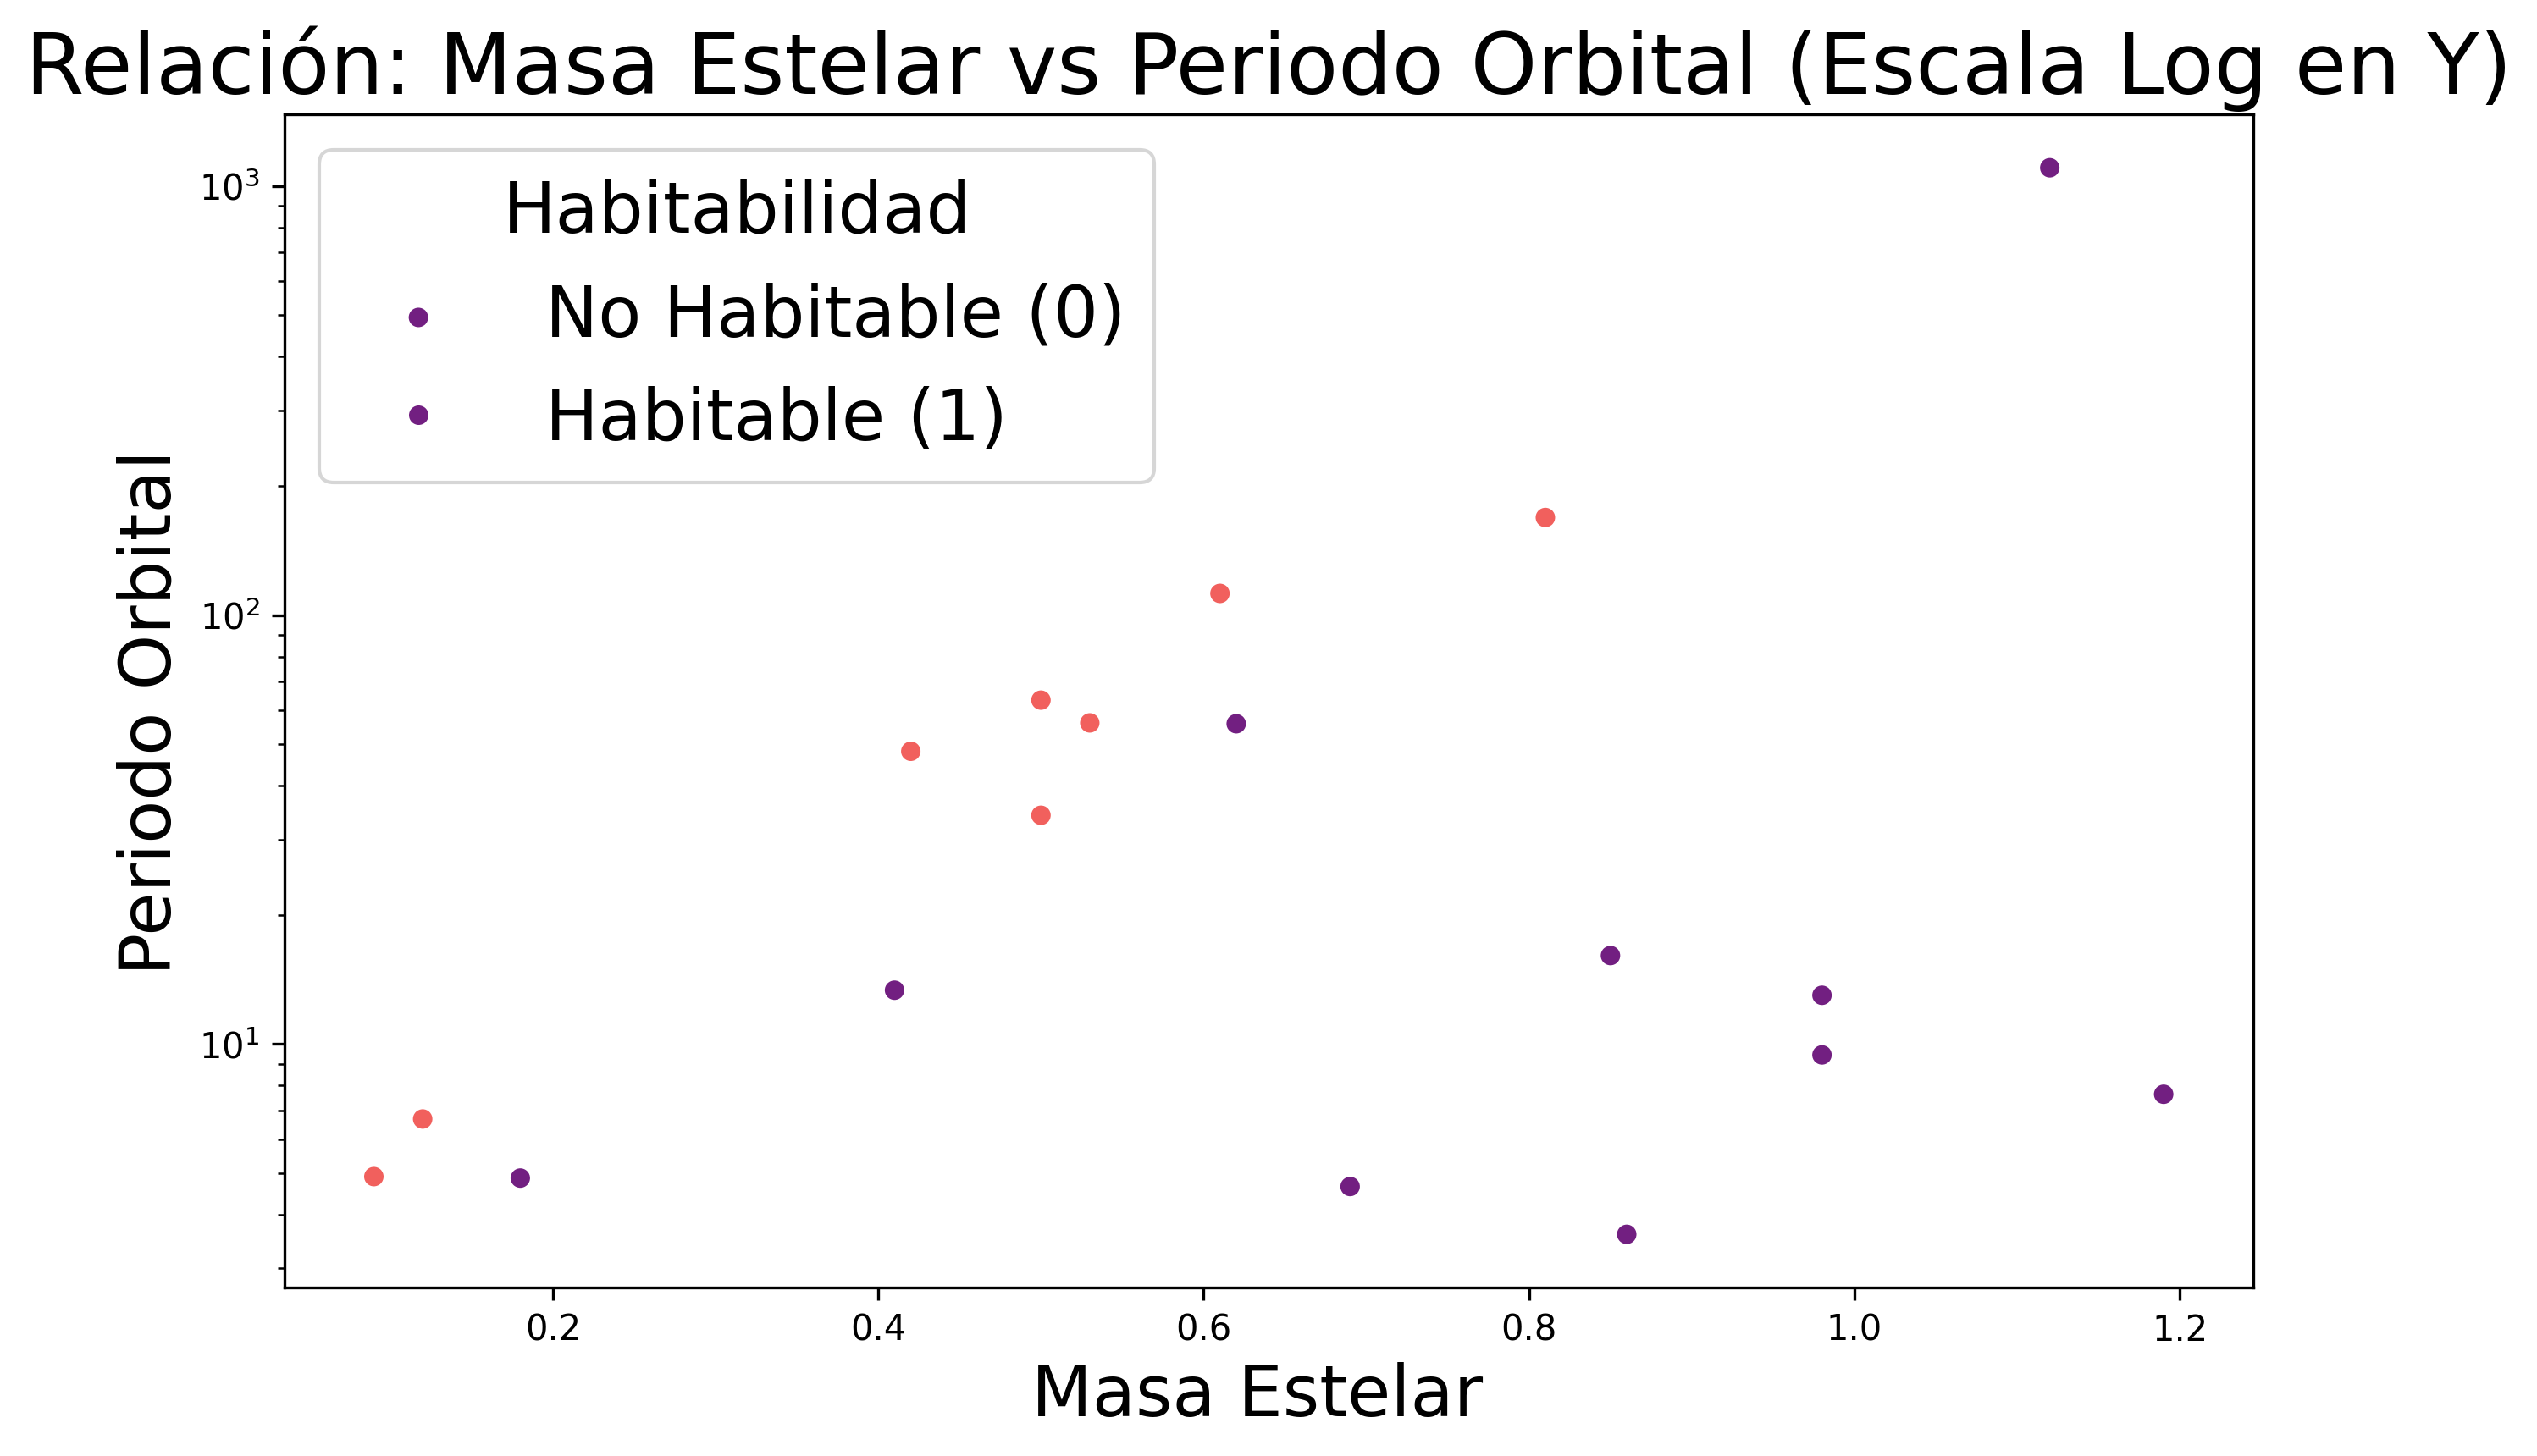

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el tamaño de la figura
plt.figure(figsize=(10, 6))

# Invertimos los ejes: x='S_MASS', y='P_PERIOD'
sns.scatterplot(data=LearningSet,x='S_MASS',y='P_PERIOD',hue='P_HABITABLE',palette='magma',alpha=1)

# Aplicamos la escala logarítmica ahora al eje Y (Periodo)
plt.yscale('log')

# Etiquetas y título
plt.title('Relación: Masa Estelar vs Periodo Orbital (Escala Log en Y)')
plt.xlabel('Masa Estelar ')
plt.ylabel('Periodo Orbital ')
plt.legend(title='Habitabilidad', labels=['No Habitable (0)', 'Habitable (1)'])

plt.show()

**Antes de entrenar un modelo, te parece que las clases se separan fácilmente o no? Explique**


Las clases se separan siguiendo la franja de la zona habitable, pero de forma diagonal, es decir, a mayor masa estelar, mayor debe ser el periodo orbital. Esto significa que los modelos no pueden usar una línea recta simple. El Árbol de Decisión tendrá que crear una "escalera" de reglas para seguir la curva

### Elijamos el set de entrenamiento y prueba

Para definir los sets de etrenamiento y prueba, haremos una división *manual*

Definimos que las primeras 13 filas del dataframe será el conjunto de entrenamiento y los últimos 5, el conjunto de prueba

> En un problema real, usualmente preferimos una división aleatoria o validación cruzada.


Usaremos .iloc para acceder a los índices del dataframe

In [65]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [66]:
TrainSet =  LearningSet.iloc[:13,:]

TestSet = LearningSet.iloc[13:,:]

In [67]:
TrainSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [68]:
TestSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
13,HD 104067 b,0.62,55.80600,0.260000,0
14,GJ 4276 b,0.41,13.35200,0.087613,0
15,Kepler-296 f,0.50,63.33627,0.268885,1
16,Kepler-63 b,0.98,9.43415,0.088100,0
17,GJ 3293 d,0.42,48.13450,0.195336,1


También necesitamos definir para cada conjunto las características (features) y los objetivos (targets)

In [69]:
Xtrain = TrainSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features conjunto de entrenamiento

Xtest = TestSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features  conjunto de entrenamiento

In [70]:
Xtrain.columns

Index(['S_MASS', 'P_PERIOD', 'P_DISTANCE'], dtype='object')

In [71]:
ytrain = TrainSet.P_HABITABLE #target conjunto prueba

ytest = TestSet.P_HABITABLE  #target conjunto prueba

In [72]:
Xtest

,S_MASS,P_PERIOD,P_DISTANCE
13,0.62,55.80600,0.260000
14,0.41,13.35200,0.087613
15,0.50,63.33627,0.268885
16,0.98,9.43415,0.088100
17,0.42,48.13450,0.195336


In [73]:
ytrain

,P_HABITABLE
0,0
1,0
2,0
3,1
4,0
5,1
6,0
7,1
8,0
9,1


### Entrenamos el modelo
Nota: En los árboles de decisión de scikit-learn, las características (o variables) se reorganizan aleatoriamente cada vez que se realiza una división para decidir cómo separar los datos. Esto significa que, incluso si se usa el mismo conjunto de datos de entrenamiento, la mejor forma de dividir los datos puede cambiar entre diferentes ejecuciones del modelo. Esta variación ocurre cuando varias divisiones posibles ofrecen la misma mejora en el criterio de evaluación (por ejemplo, reducir la impureza del nodo). En estos casos, el algoritmo puede elegir diferentes divisiones como "mejores" en diferentes ejecuciones debido al orden aleatorio en que se evalúan las características.

Para asegurar que los resultados del entrenamiento sean consistentes y reproducibles (es decir, que se obtenga el mismo árbol de decisión cada vez que se entrene con los mismos datos), es necesario fijar el parámetro random_state. Esto establece una semilla para el generador de números aleatorios utilizado por el algoritmo, garantizando que la permutación de las características sea la misma en cada ejecución y, por lo tanto, el resultado del modelo también sea el mismo.

In [74]:
from sklearn.tree import DecisionTreeClassifier #modelo de árbol de decisión


In [75]:
model = DecisionTreeClassifier(random_state = 3) #Inicializamos el modelo con sus parámetros

model.fit(Xtrain, ytrain) #En una línea, construimos el modelo

DecisionTreeClassifier(random_state=3)

### Podemos visualizar el árbol (visualización "pro")

debe instalar la libreria [`pydotplus`](https://pypi.org/project/pydotplus/)  y [`graphviz`](https://pypi.org/project/graphviz/)

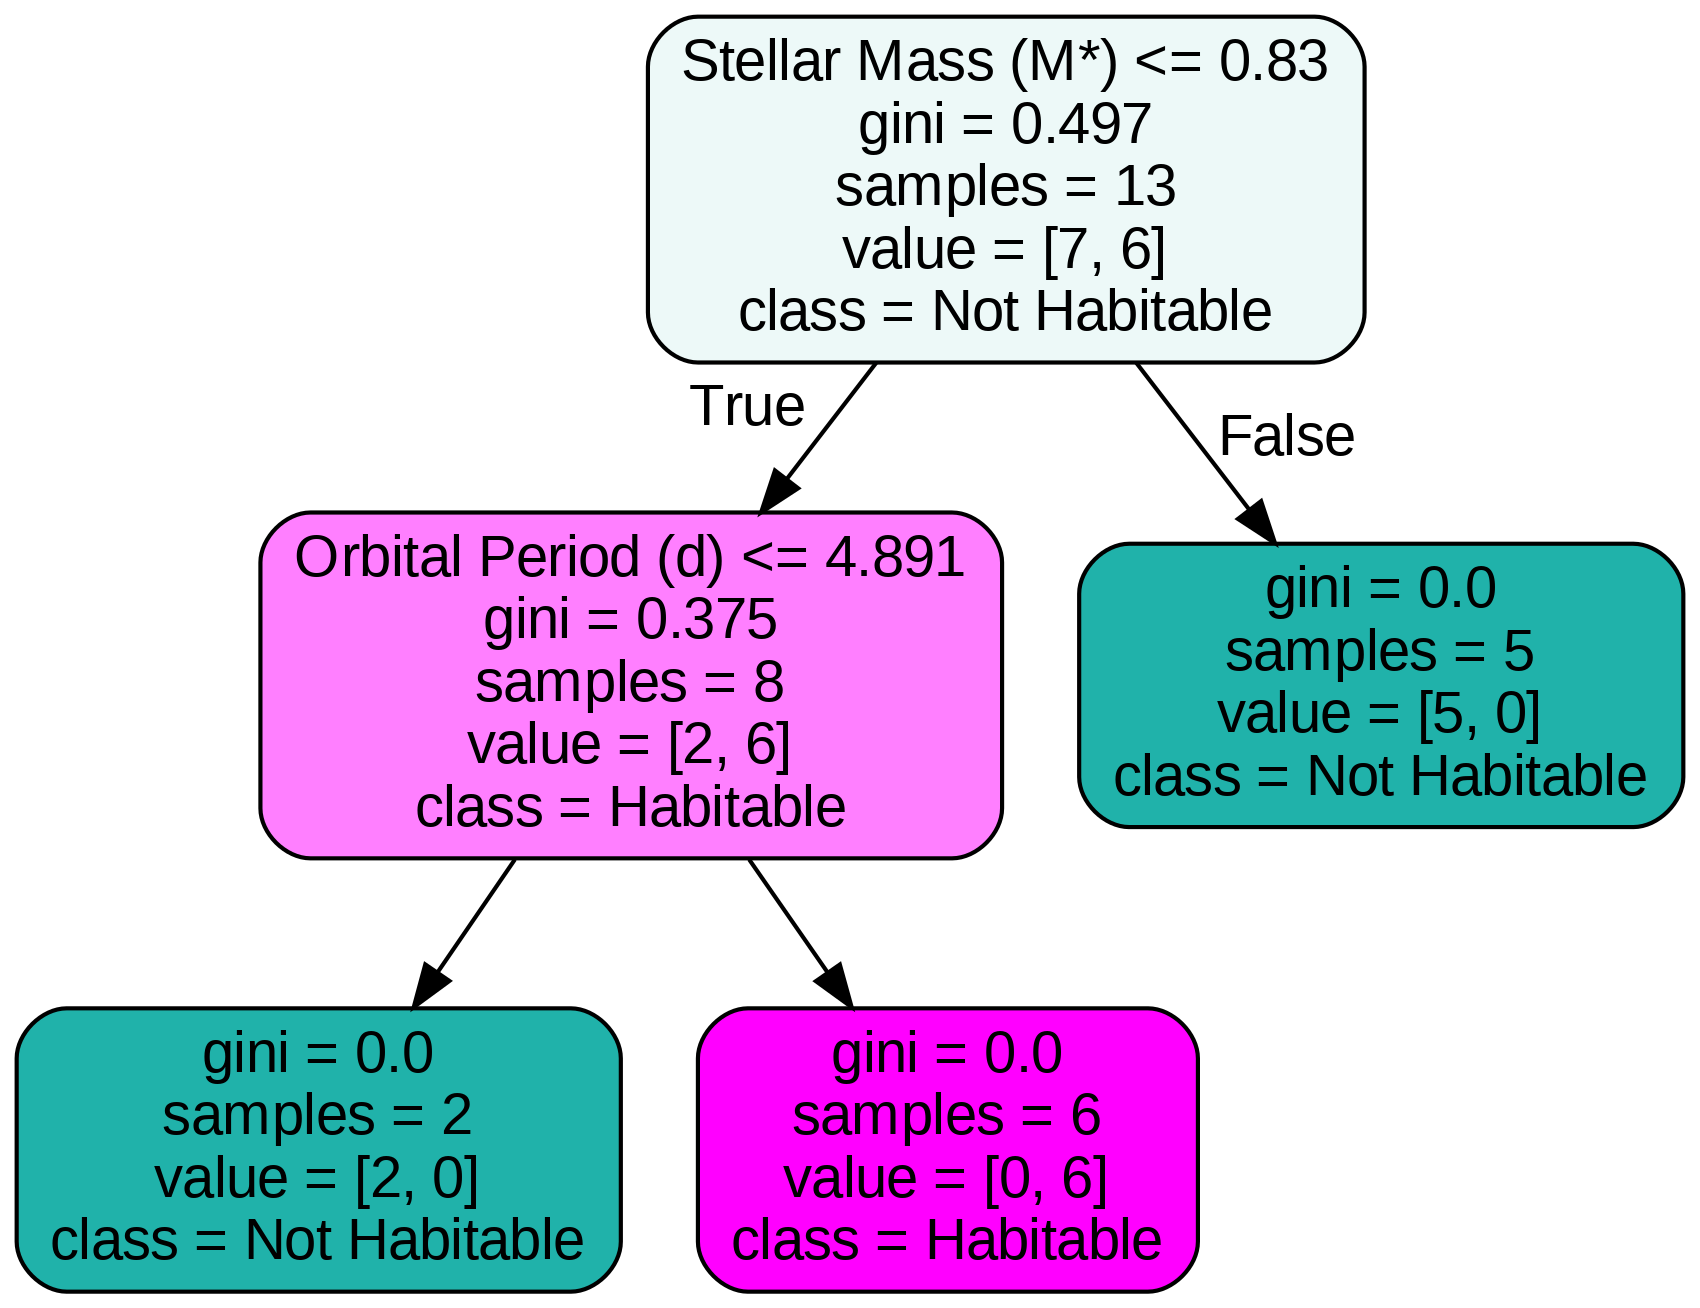

In [76]:
dot_data = StringIO()
export_graphviz(
            model,
            out_file =  dot_data,
            feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
            class_names = ['Not Habitable','Habitable'],
            filled = True,
            rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label():
        values = [int(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [255 * v / sum(values) for v in values]

        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha) #turn into hexadecimal
            color = '#20 B2 AA'+str(alpha)
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#FF 00 FF'+str(alpha)
        node.set_fillcolor(color)

graph.set_dpi('300')

Image(graph.create_png())

#Image(graph.write_png('Graph.png'))

### Visualización de sklearn

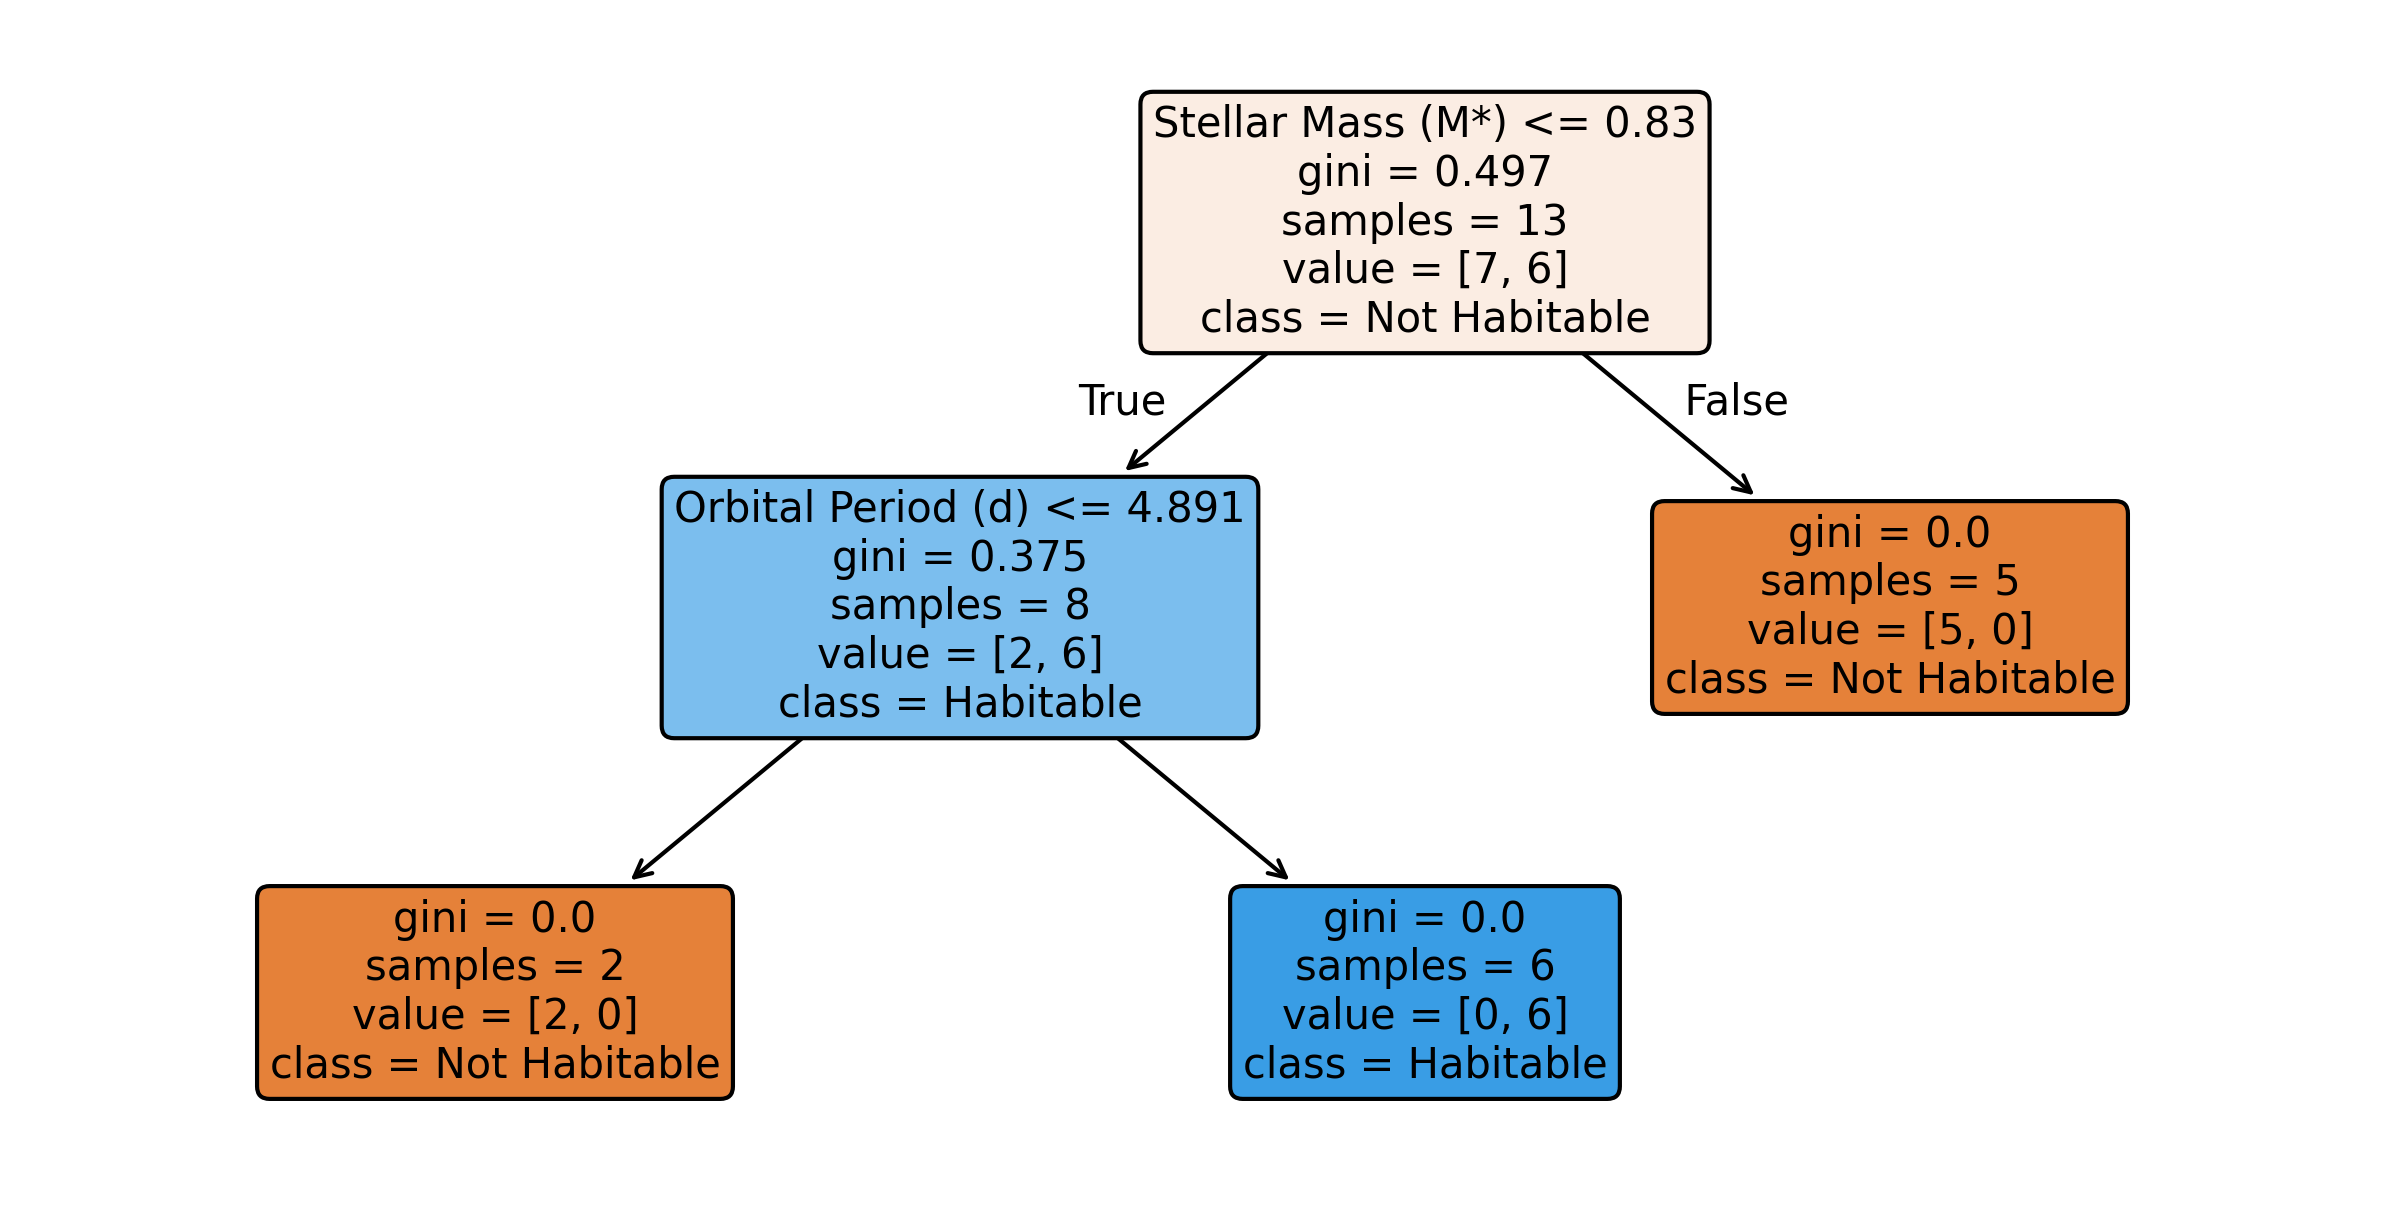

In [77]:
from sklearn import tree

plt.figure(figsize=(10,5))  # puede cambiar de acuerdo al tamaño del árbol
tree.plot_tree(model,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

### También podemos visualizar las decisiones del clasificador. El color de sombreado predice la etiqueta, y el color de los puntos marca la etiqueta real:

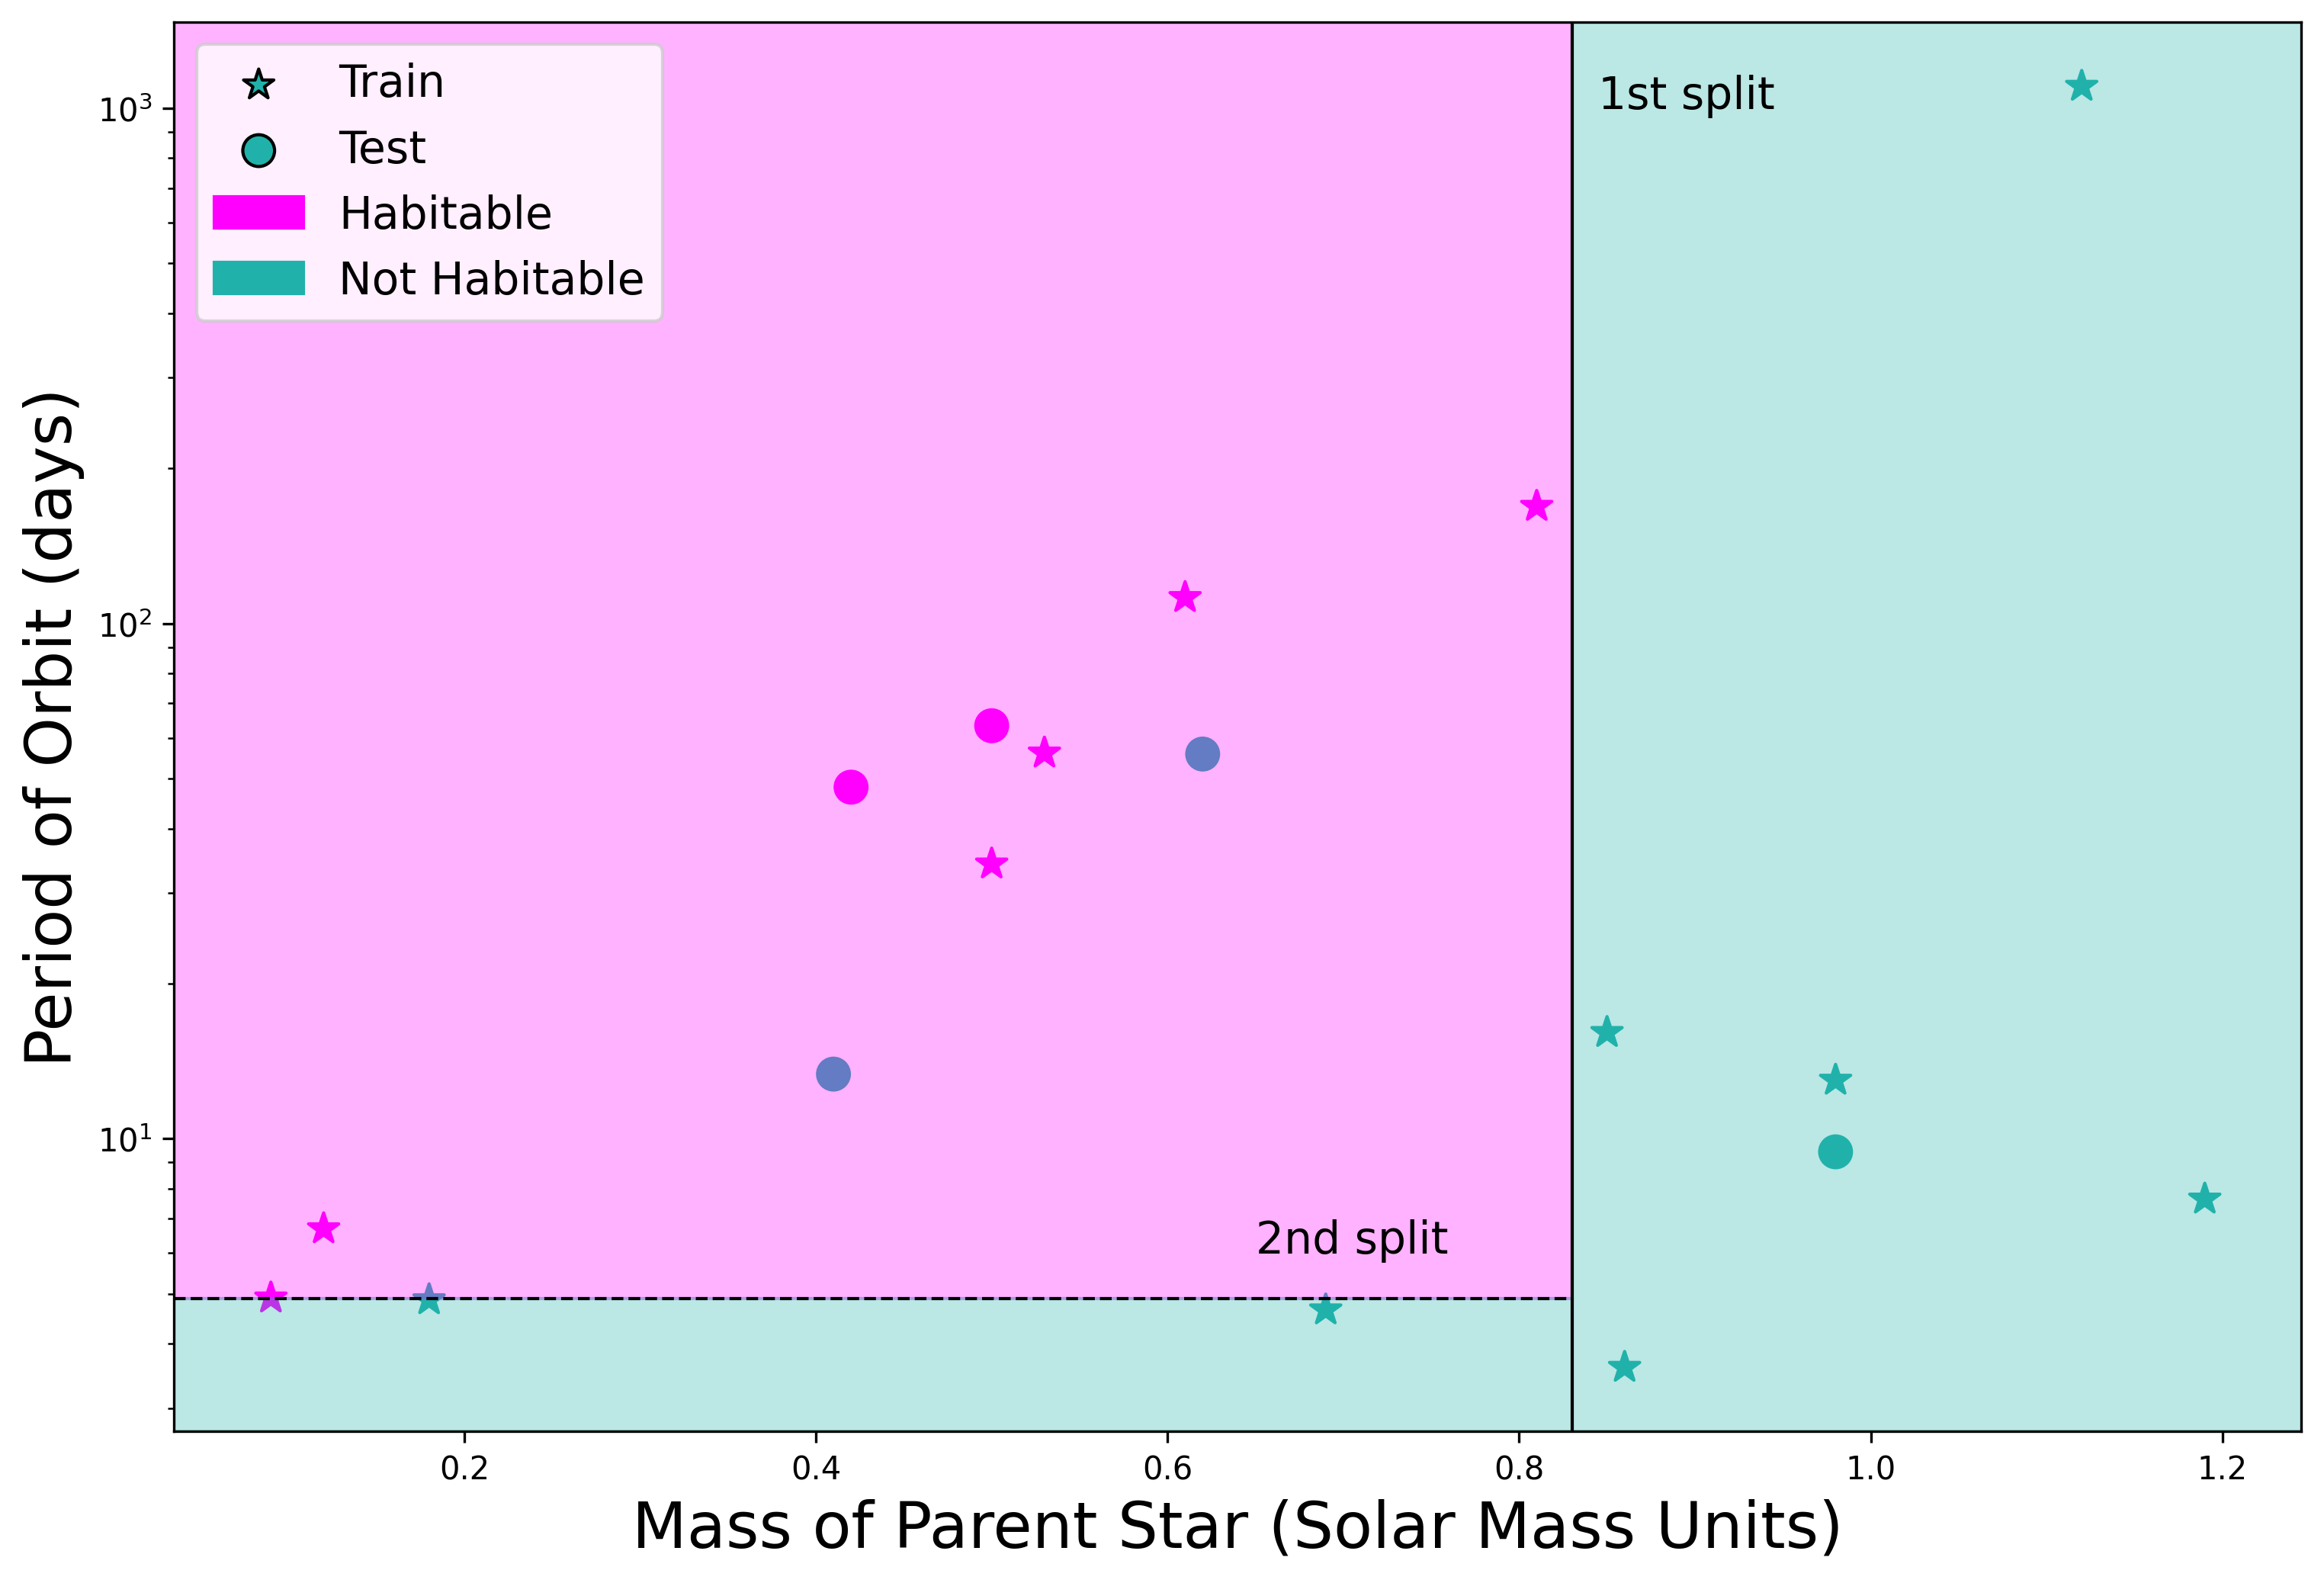

In [78]:
plt.figure(figsize=(12,8))

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

#puntos de entrenamiento y prueba

plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',\
            c = TrainSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Train')

plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',\
            c = TestSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Test')

plt.yscale('log')

plt.xlabel('Mass of Parent Star (Solar Mass Units)')

plt.ylabel('Period of Orbit (days)');

#splits del gráfico

plt.axvline(x=0.83, linewidth =1, ls = '-', label = '1st split', c='k')

plt.axhline(y=4.891, xmin = 0, xmax = 0.655, linewidth =1, ls = '--', label = '2nd split',c='k')

plt.text(0.845, 10**3, '1st split', fontsize=14)

plt.text(0.65, 6, '2nd split', fontsize=14)

#leyenda

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')

magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()

predhab = mpatches.Rectangle((0,4.891),0.83,ax.get_ylim()[1],
                        fill = True,
                        color = '#FF00FF',
                        alpha = 0.3)

prednothab1 = mpatches.Rectangle((0.83,ax.get_ylim()[0]),ax.get_xlim()[1],ax.get_ylim()[1],
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

prednothab2 = mpatches.Rectangle((0,ax.get_ylim()[0]),0.83,4.891-ax.get_ylim()[0],
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')

plt.gca().add_patch(predhab)
plt.gca().add_patch(prednothab1)
plt.gca().add_patch(prednothab2)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14);


### Pregunta
    
- ¿Cuál es el porcentaje de clasificaciones correctas en el set de entrenamiento?  Y en el set de prueba?

Tiene un 60% de prediccion en el set

A este porcentaje de clasificaciones correctas lo llamaremos **accuracy**

### usando la métricas de sklearn, podemos encontrar el accuracy


In [79]:
import sklearn.metrics as metrics


In [80]:
ypred = model.predict(Xtest) #generamos etiquetas de predicción en el set de prueba

In [81]:
ypred

array([1, 1, 1, 0, 1])

Accuracy es una métrica usual para evaluar modelos de clasificación, y hay una función en el módulo `sklearn.metrics`. Tenemos que comparar los resultados de la predicción `ypred` con los valores reales `ytest`

In [82]:
metrics.accuracy_score(ytest, ypred) #test score

0.6

también podemos encontrar el accuracy de los datos de entrenamiento, generando predicciones para los `Xtrain` y comparando con el `ytrain`

In [83]:
metrics.accuracy_score(ytrain, model.predict(Xtrain)) #train score

1.0

### Preguntas de interpretación
1. ¿El árbol clasifica perfectamente el conjunto de entrenamiento?

El árbol clasifica perfectamente el conjunto de entrenamiento con un accuracy de 1.0, lo que significa que el algoritmo logró crear reglas específicas para cada uno de los 13 ejemplos.

2. ¿Qué ocurre en el conjunto de prueba?

En el conjunto de prueba el accuracy baja a 0.6, lo cual es un resultado bastante pobre. Esto nos confirma que el modelo sufre de sobreajuste, porque las reglas tan exactas que funcionaron con los datos conocidos no sirven para predecir correctamente la habitabilidad en planetas nuevos.

3. ¿Qué variable aparece en la raíz del árbol?

La variable que aparece en la raíz del árbol es la masa estelar.

4. ¿Te parece que este árbol es simple o ya es relativamente profundo para un dataset tan pequeño?

Me parece que el árbol es demasiado profundo para tener un dataset tan pequeño. Al tener solo 13 filas de entrenamiento, un árbol con tantos niveles y cortes se vuelve muy complejo y específico, cuando lo ideal para asegurar la generalización hubiera sido un modelo mucho más simple y con menos ramas.


### Ahora elegiremos un set de entrenamiento distinto. Las 5 primeras filas serán de prueba y el resto será para el entrenamiento

In [84]:
# los primeros 5 de prueba, el resto de entrenamiento
TrainSet2 = LearningSet.iloc[5:,:]

TestSet2 = LearningSet.iloc[:5,:]

### Repita el proceso anterior

1. Defina los dataframes de características y la serie de categorías para entrenamiento y prueba: `Xtrain2`, `Xtest2`, `ytrain2`, `ytest2`
2. inicialice el modelo de árbol de decisión para clasificación (defina semilla `random_state=3`
3. ajuste el modelo a los datos de entrenamiento
4. visualice el árbol
5. calcule accuracy para entrenamiento y prueba

In [85]:
# Definir características (features) y objetivos (targets) para la partición 2
Xtrain2 = TrainSet2.drop(['P_NAME','P_HABITABLE'], axis=1)
Xtest2 = TestSet2.drop(['P_NAME','P_HABITABLE'], axis=1)

ytrain2 = TrainSet2.P_HABITABLE
ytest2 = TestSet2.P_HABITABLE

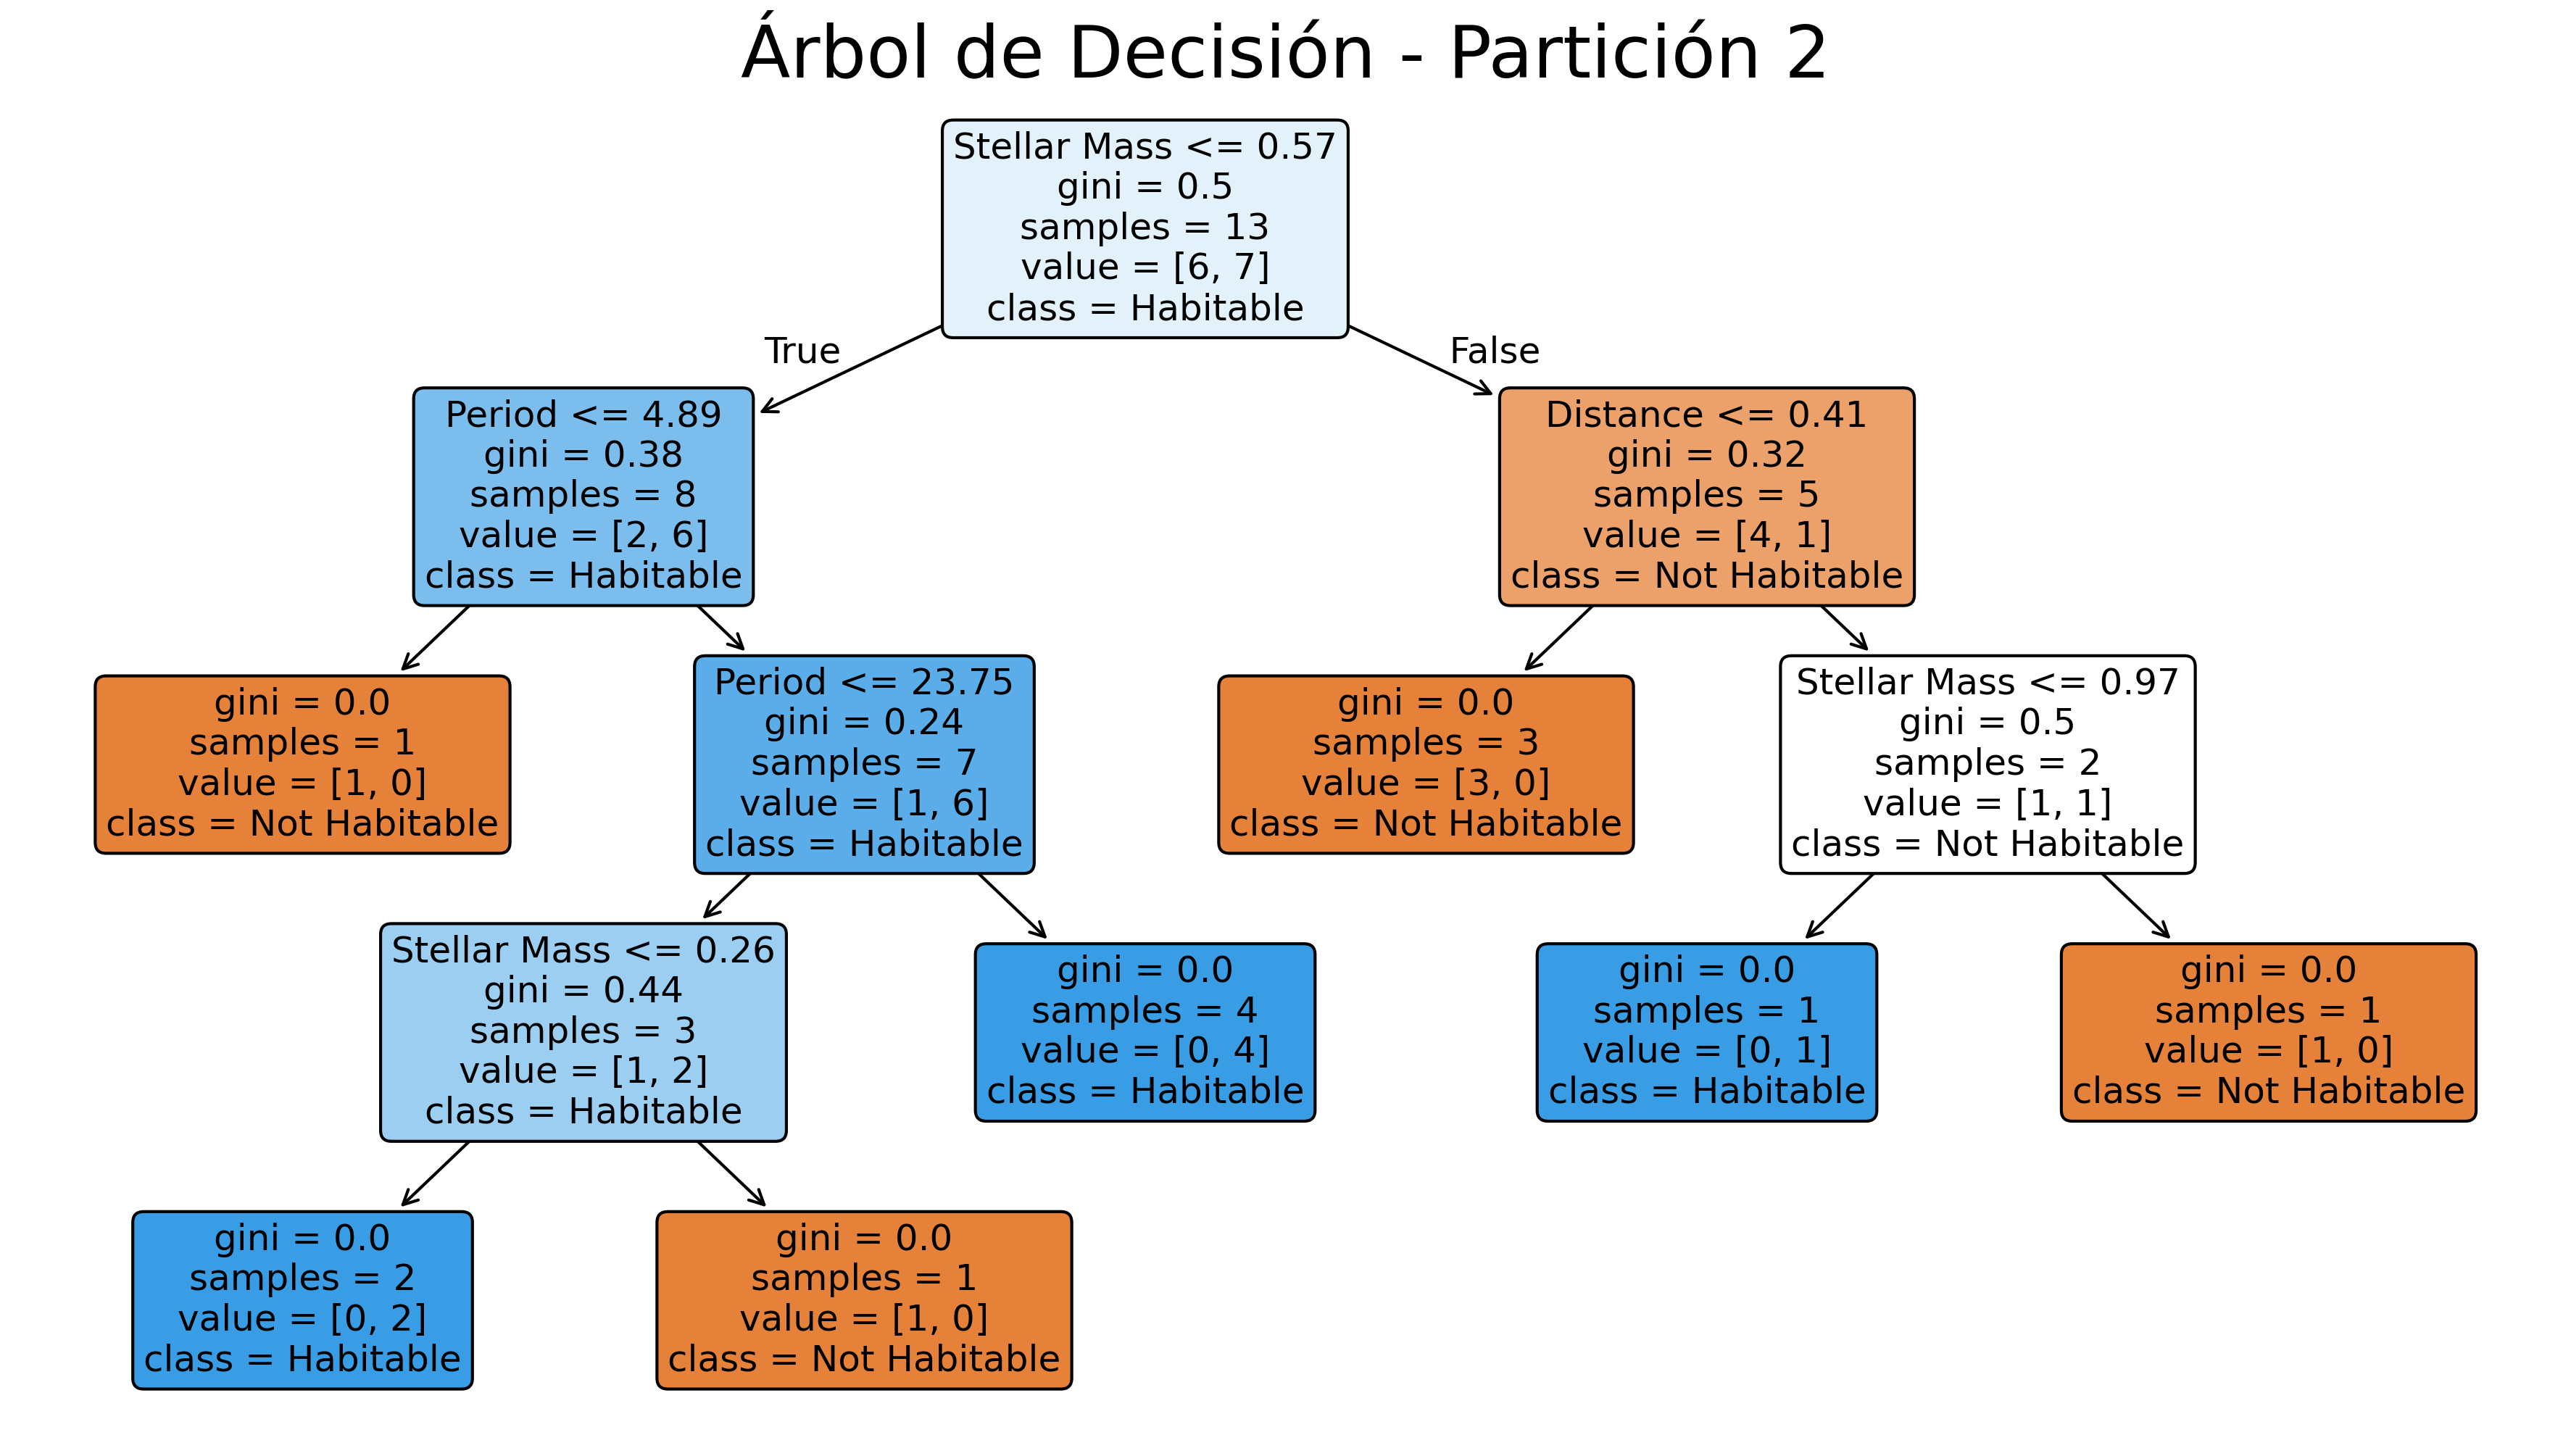

In [86]:
# Inicializar el modelo con la semilla random_state=3
model2 = DecisionTreeClassifier(random_state=3)

# Ajustar el modelo
model2.fit(Xtrain2, ytrain2)

plt.figure(figsize=(15, 8)) # Aumentamos el ancho a 15 y alto a 8

tree.plot_tree(model2,
               feature_names = ['Stellar Mass', 'Period', 'Distance'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=12,
               precision=2)

plt.title("Árbol de Decisión - Partición 2")
plt.show()


In [87]:
# Predicciones
ypred2 = model2.predict(Xtest2)

# Cálculo de scores
train_score2 = metrics.accuracy_score(ytrain2, model2.predict(Xtrain2))
test_score2 = metrics.accuracy_score(ytest2, ypred2)

print(f"Accuracy en el set de entrenamiento (Partición 2): {train_score2}")
print(f"Accuracy en el set de prueba (Partición 2): {test_score2}")

Accuracy en el set de entrenamiento (Partición 2): 1.0
Accuracy en el set de prueba (Partición 2): 1.0


### Preguntas:

- Compare el árbol de decisión inicial vs el obtenido ahora. Nota alguna diferencia?

Es más complejo, tiene muchas ramas, usó distancia orbital. Esto demuestra que el modelo es sensible, con solo mover un par de planetas, la estructura lógica del árbol se reorganiza por completo.

- ¿Cuál es el accuracy (porcentaje de clasificaciones correctas) en el conjunto de entrenamiento?

El accuracy es 1.0 (100%).

- ¿Y en el conjunto de prueba?

En esta segunda partición, el accuracy es 1.0. Es un salto enorme comparado con el 0.6 del primer ejercicio. Esto significa que, por puro azar de la distribución, las reglas que el modelo aprendió con los nuevos datos de entrenamiento coincidieron exactamente con la ubicación de los 5 planetas que dejamos para el test.

- Si ahora el resultado es mejor, ¿significa automáticamente que este árbol es “mejor” en general?

No necesariamente. Que hayamos obtenido un 100% en el test no significa que el modelo sea superior, sino que tuvimos "suerte" con la partición de los datos. Por lo tanto el modelo es inestable.


### Conclusiones

- Que puede concluir respecto a al ejercicio?

El Árbol de Decisión tiende al sobreajuste. Mientras que otros modelos se confunden con el ruido, el árbol es capaz de memorizar el entrenamiento (accuracy 1.0), lo que obliga a validar siempre con el set de prueba para confirmar si realmente aprendió a generalizar o solo memorizó los casos.

- Cambian los resultados dependiendo del set de datos que utilizamos?

Al cambiar la partición de los datos los resultados cambian, ya que el árbol se adapta de forma extrema a los ejemplos específicos que recibe.

- ¿Sería la Tierra clasificada como habitable por alguno de estos árboles?

La Tierra sería clasificada como no habitable debido al sesgo de los datos actuales. Como la mayoría de los exoplanetas descubiertos orbitan estrellas pequeñas en distancias muy cortas, el árbol crea reglas basadas en esos sistemas específicos.

## k-Nearest Neighbors

Aplicaremos ahora kNN al mismo problema.

>kNN clasifica según las etiquetas de los `k` vecinos más cercanos, es un método basado en distancia, por eso la **escala** de las variables sí importa.




In [88]:
from sklearn import neighbors
import sklearn

Para el mismo set de datos de habitabilidad de planetas

In [89]:
Xtrain

,S_MASS,P_PERIOD,P_DISTANCE
0,0.86,3.601472,0.043718
1,0.85,16.080661,0.118082
2,1.19,7.638460,0.080420
3,0.61,112.305300,0.409327
4,0.98,12.992073,0.107408
5,0.09,4.910000,0.025200
6,0.69,4.655411,0.048086
7,0.12,6.689000,0.035000
8,1.12,1103.000000,2.180981
9,0.81,168.811170,0.557107


### "Entrenamos" el modelo
Es un algoritmo sencillo basado en la idea de distancia: buscamos los k (un número entero) objetos que están más cerca del que queremos clasificar, y tomamos la votación de la mayoría entre las k clases de los k vecinos.

kNN es un algoritmo basado en instancias (también llamado **"lazy learning"**), sigue necesitando saber con qué datos va a comparar para hacer predicciones futuras. El método fit le dice al algoritmo con qué datos va a trabajar.

El método fit en kNN no ajusta parámetros del modelo como en otros algoritmos.
Simplemente almacena los datos de entrenamiento para su uso durante la predicción.
Durante la predicción, el algoritmo calcula las distancias entre el nuevo punto y los puntos de entrenamiento almacenados para encontrar los k vecinos más cercanos y decidir la clase del nuevo punto basado en una votación mayoritaria.
En esencia, el proceso de "ajuste" en kNN es solo la configuración de los datos de referencia para comparaciones futuras, no un ajuste de parámetros basado en optimización.









In [90]:
model = neighbors.KNeighborsClassifier(n_neighbors = 3) #elegimos los 3 vecinos más cercanos

In [91]:
model

KNeighborsClassifier(n_neighbors=3)

#### Para propósitos de visualización, usemos solo las dos primeras características para construir el modelo.

In [92]:
Xtrain.iloc[:,:2]

,S_MASS,P_PERIOD
0,0.86,3.601472
1,0.85,16.080661
2,1.19,7.638460
3,0.61,112.305300
4,0.98,12.992073
5,0.09,4.910000
6,0.69,4.655411
7,0.12,6.689000
8,1.12,1103.000000
9,0.81,168.811170


#### Se construye el modelo aplicando el método .fit al conjunto de entrenamiento. Luego, predice las etiquetas para el conjunto de prueba.

In [93]:
model.fit(Xtrain.iloc[:,:2],ytrain) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred = model.predict(Xtest.iloc[:,:2]) #esto ajsta el modelo en los datos de prueba

In [94]:
ytestpred, ytest.values #comparacion

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

#### Calculando accuracy en los sets de entrenamiento y prueba

In [95]:
print(metrics.accuracy_score(ytrain, model.predict(Xtrain.iloc[:,:2]))) #Esto compara las etiquetas reales del set de entrenamiento con las etiquetas predichas para el test de entrenamiento

print(metrics.accuracy_score(ytest, model.predict(Xtest.iloc[:,:2]))) #mismo que anterior, pero para set de prueba

0.6923076923076923
0.8


#### Después de ajustar y la predicción, podemos ver los k neighbors que encontró el modelo en el conjunto de prueba

In [96]:
model.kneighbors(Xtest.iloc[:,:2]) #el primer elemento es la distancia, el segundo los índices de cada vecinos

(array([[ 0.26575741, 21.66422235, 39.72600482],
        [ 0.67412717,  2.76390862,  5.76653597],
        [ 7.28027781, 29.19416   , 47.25690512],
        [ 1.807928  ,  2.87670841,  3.5579225 ],
        [ 7.9223177 , 13.99261869, 32.05672308]]),
 array([[11, 10,  1],
        [ 4,  1,  2],
        [11, 10,  1],
        [ 2,  7,  4],
        [11, 10,  1]]))

### Visualizando los resultados

USamos la distancia del tercer vecino como el radio del círculo que encierra vecinos


In [97]:
for i in range(len(TestSet)): # para cada elemento del set de prueba

    print(model.kneighbors(Xtest.iloc[:,:2])[0][i,2]) # muestra el tercer elemento del vector de distancia

39.7260048163029
5.766535965914376
47.2569051246575
3.5579225
32.05672308015779


El siguiente código dibuja un círculo incluyendo a los 3 vecinos más cercanos para cada punto

### Nota: Para la aplicación real (no la visualización), debiéramos usar todas las features disponibles

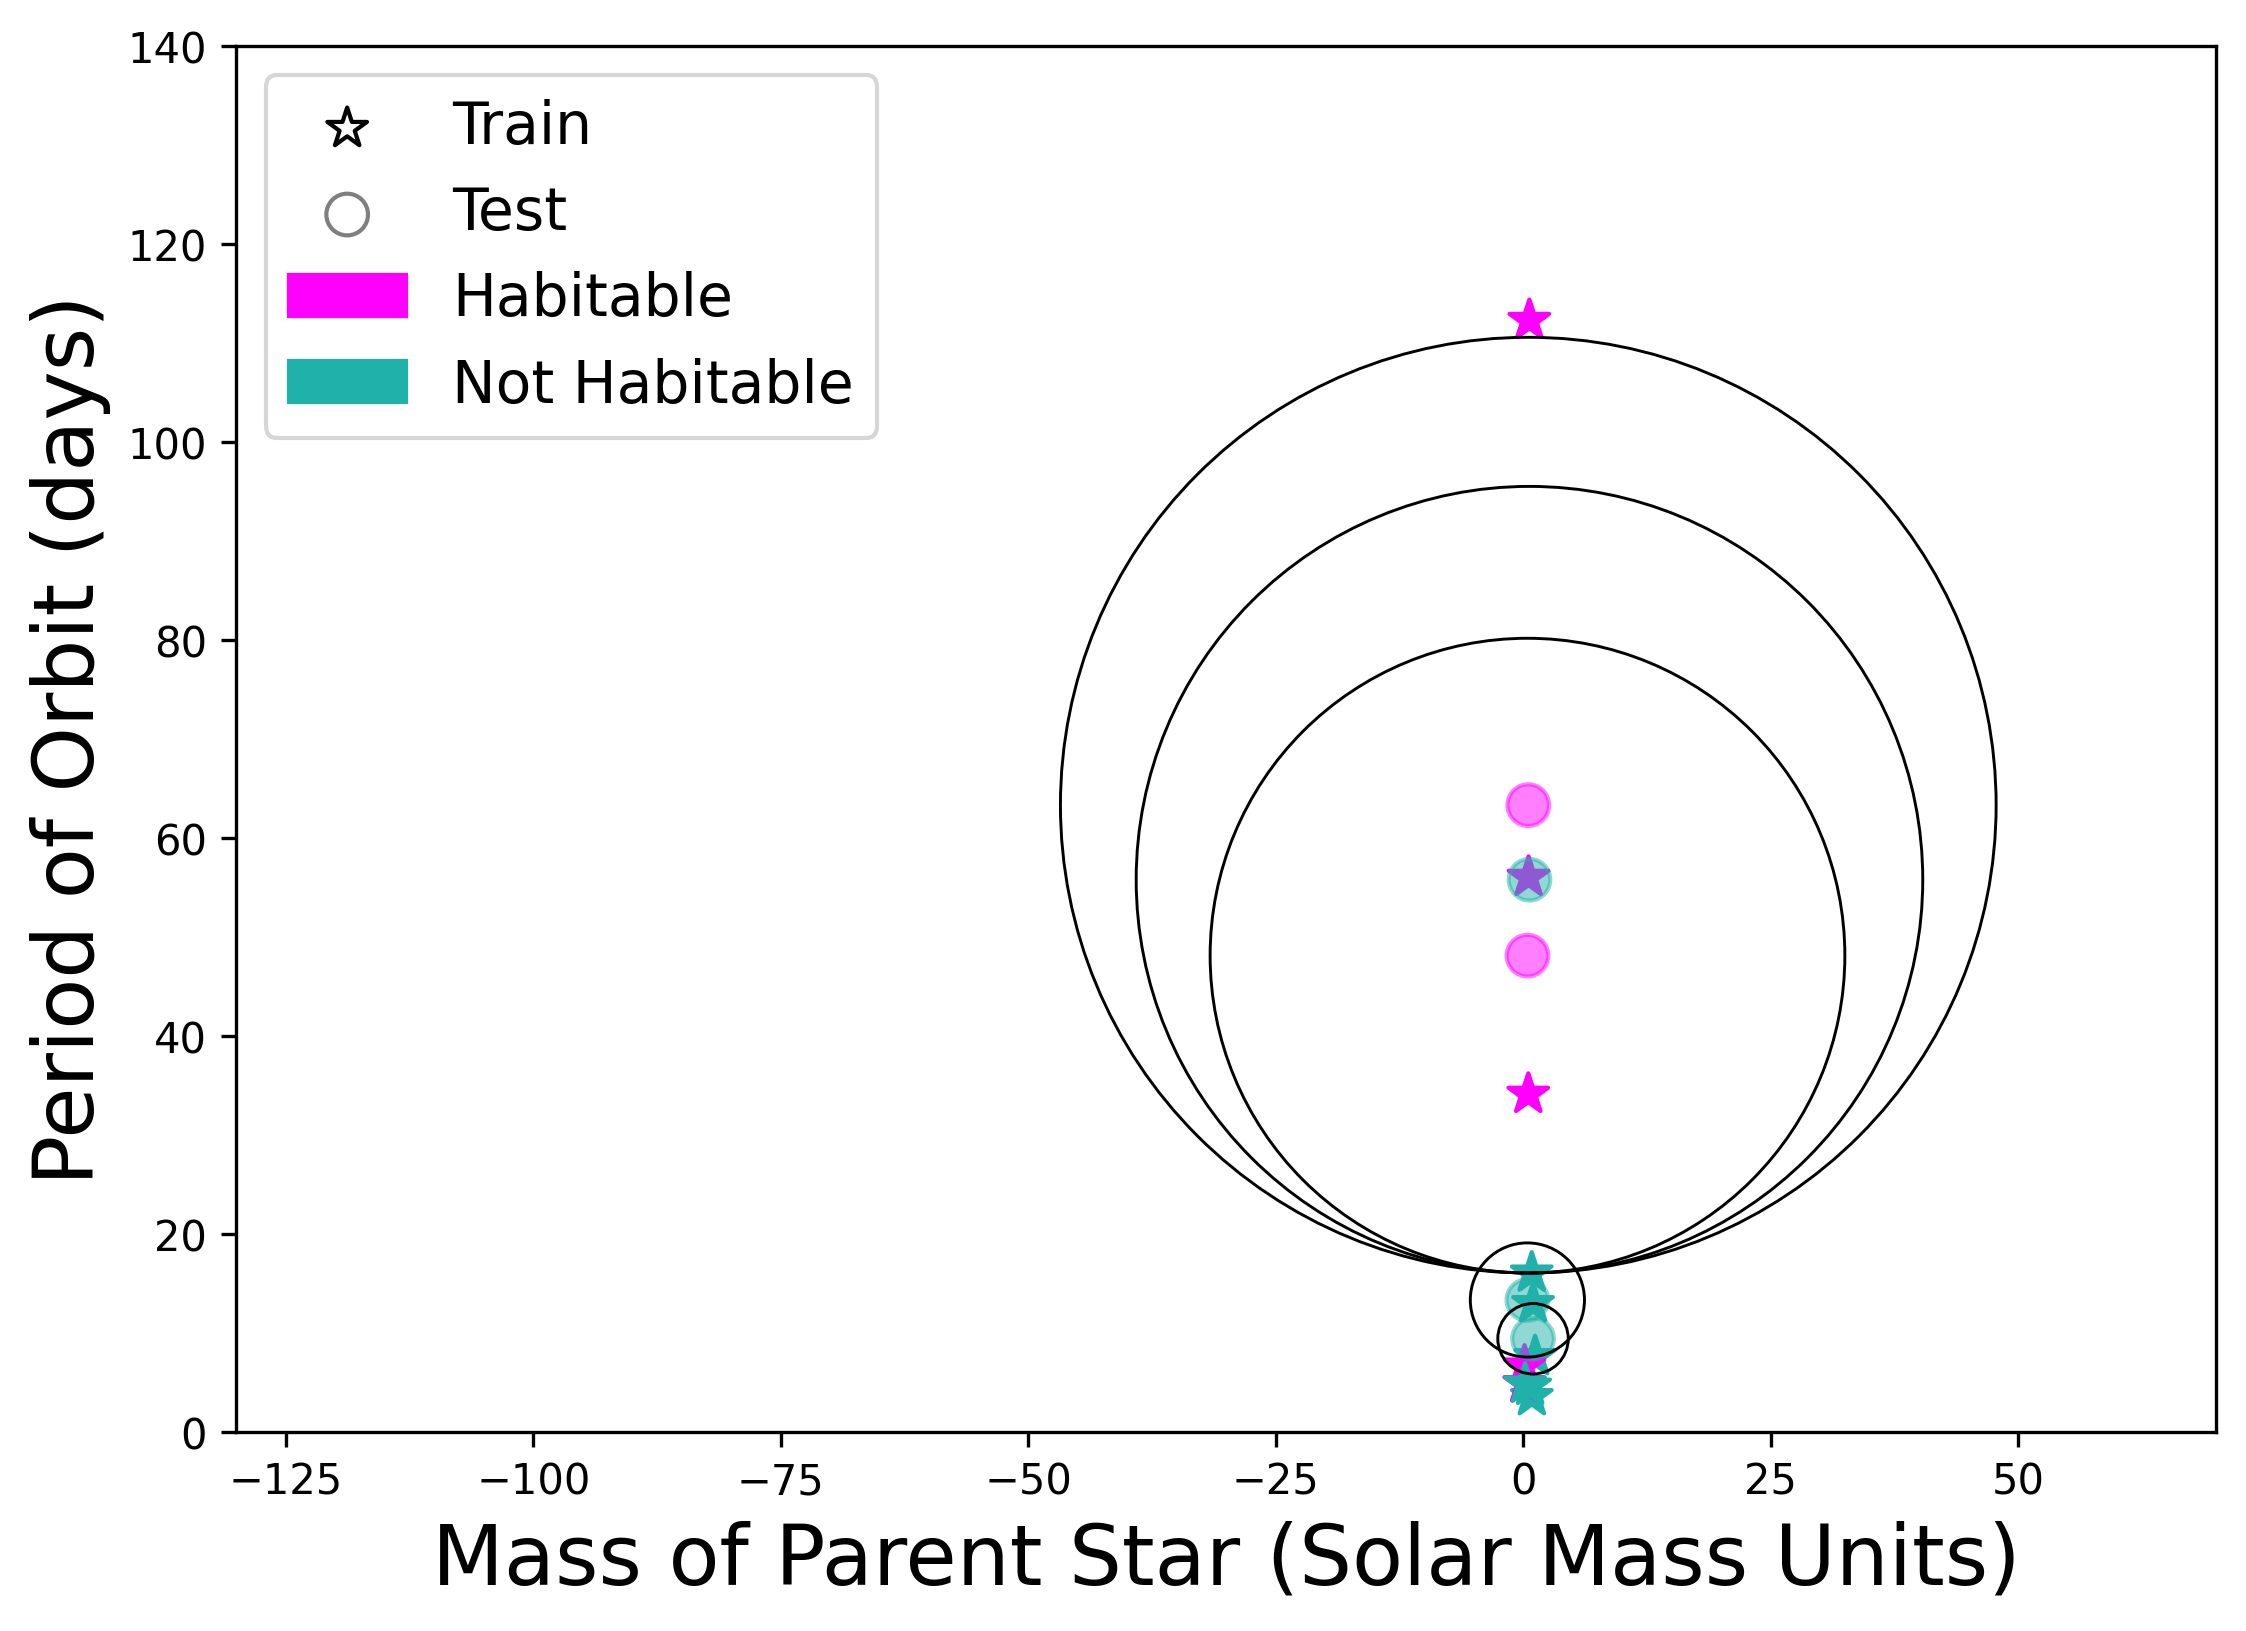

In [98]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])


a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
            c = TrainSet['P_HABITABLE'], s = 100, label = 'Train', cmap=cmap)

#a.set_facecolor('none')


a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\
            c = TestSet['P_HABITABLE'], s = 100, label = 'Test', cmap=cmap, alpha=0.5)

#a.set_facecolor('none')

for i in range(len(TestSet)): #plot neighbors

    circle1=plt.Circle((TestSet['S_MASS'].iloc[i],TestSet['P_PERIOD'].iloc[i]),model.kneighbors(Xtest.iloc[:,:2])[0][i,2],\
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)

plt.gca().set_aspect(1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14)

plt.xlim(-130,70)
plt.ylim(0,140)
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');

#plt.savefig('HabPlanetsKNN2features.png', dpi = 300)

### Nota algo particular en el gráfico?

 **Si una dimensión tiene un rango mucho mayor que las otras, dominará el proceso de decisión. Este problema se puede solucionar mediante el <b>escalado</b>. El escalado es un paso de preprocesamiento muy importante para la mayoría de los algoritmos de aprendizaje automático.**



Algunos ejemplos de algoritmos de Scaler [aquí](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html).

Usaremos [`RobustScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html), que se comporta mejor con outliers que la versión estándar, ya que escala de acuerdo a percentiles. Específicamente, usa la mediana (percentil 50) y el rango intercuartílico (IQR = Q3 - Q1), lo cual lo hace menos sensible a valores extremos


In [99]:
scaler = sklearn.preprocessing.RobustScaler() #inicializamos el Scaler

#### Importante!!

Debemos ajustar el escalador **sólo con los datos de entrenamiento**. Esto se hace porque **el modelo no debe tener acceso a los datos de prueba durante el entrenamiento**. Si usamos los datos de prueba para ajustar el escalador, estaríamos filtrando información del futuro, lo que se conoce como data leakage.

Esto puede llevar a dos problemas: por un lado, el modelo podría parecer más preciso de lo que realmente es, y por otro, podría aprender patrones que no se generalizan bien a datos nuevos, lo que se traduce en sobreajuste.

Para evitar esto, primero se ajusta el escalador con los datos de entrenamiento (`fit`), y luego se usa ese mismo escalador para transformar tanto el entrenamiento como el test (`transform`).

In [100]:
scaler.fit(Xtrain) # importante: solo escalamos el set de entrenamiento

RobustScaler()

In [101]:
scaledXTrain = scaler.transform(Xtrain)

In [102]:
scaledXTrain

array([[ 0.47222222, -0.18360363, -0.33840183],
       [ 0.44444444,  0.06038761,  0.05671512],
       [ 1.38888889, -0.10467304, -0.14339694],
       [-0.22222222,  1.94175736,  1.60417741],
       [ 0.80555556,  0.        ,  0.        ],
       [-1.66666667, -0.15801948, -0.43679409],
       [ 0.        , -0.16299717, -0.31519247],
       [-1.58333333, -0.12323674, -0.38472405],
       [ 1.19444444, 21.311672  , 11.01745224],
       [ 0.33333333,  3.04655169,  2.38937206],
       [-0.52777778,  0.41352236,  0.3761471 ],
       [-0.44444444,  0.84198052,  0.66159817],
       [-1.41666667, -0.15877753, -0.40201197]])

In [103]:
scaledXtest = scaler.transform(Xtest) #

In [104]:
scaler.inverse_transform #esto invierte el escalado si es necesario

<bound method RobustScaler.inverse_transform of RobustScaler()>

**Ahora, con los datos escalados, aplique el modelo de kNN inicializado anteriormente, genere las predicciones y genere la misma visualización que en el caso anterior**

In [105]:
# Entrenamos el modelo kNN (k=3) con los datos escalados
# Usamos solo las primeras dos columnas (Masa y Periodo) para que coincida con la visualización
model_scaled = neighbors.KNeighborsClassifier(n_neighbors=3)
model_scaled.fit(scaledXTrain[:, :2], ytrain)

# Generamos las predicciones para el set de prueba escalado
ypred_scaled = model_scaled.predict(scaledXtest[:, :2])

# Calculamos el Accuracy
print(f"Accuracy Entrenamiento (Escalado): {metrics.accuracy_score(ytrain, model_scaled.predict(scaledXTrain[:, :2]))}")
print(f"Accuracy Prueba (Escalado): {metrics.accuracy_score(ytest, ypred_scaled)}")

Accuracy Entrenamiento (Escalado): 0.8461538461538461
Accuracy Prueba (Escalado): 0.8


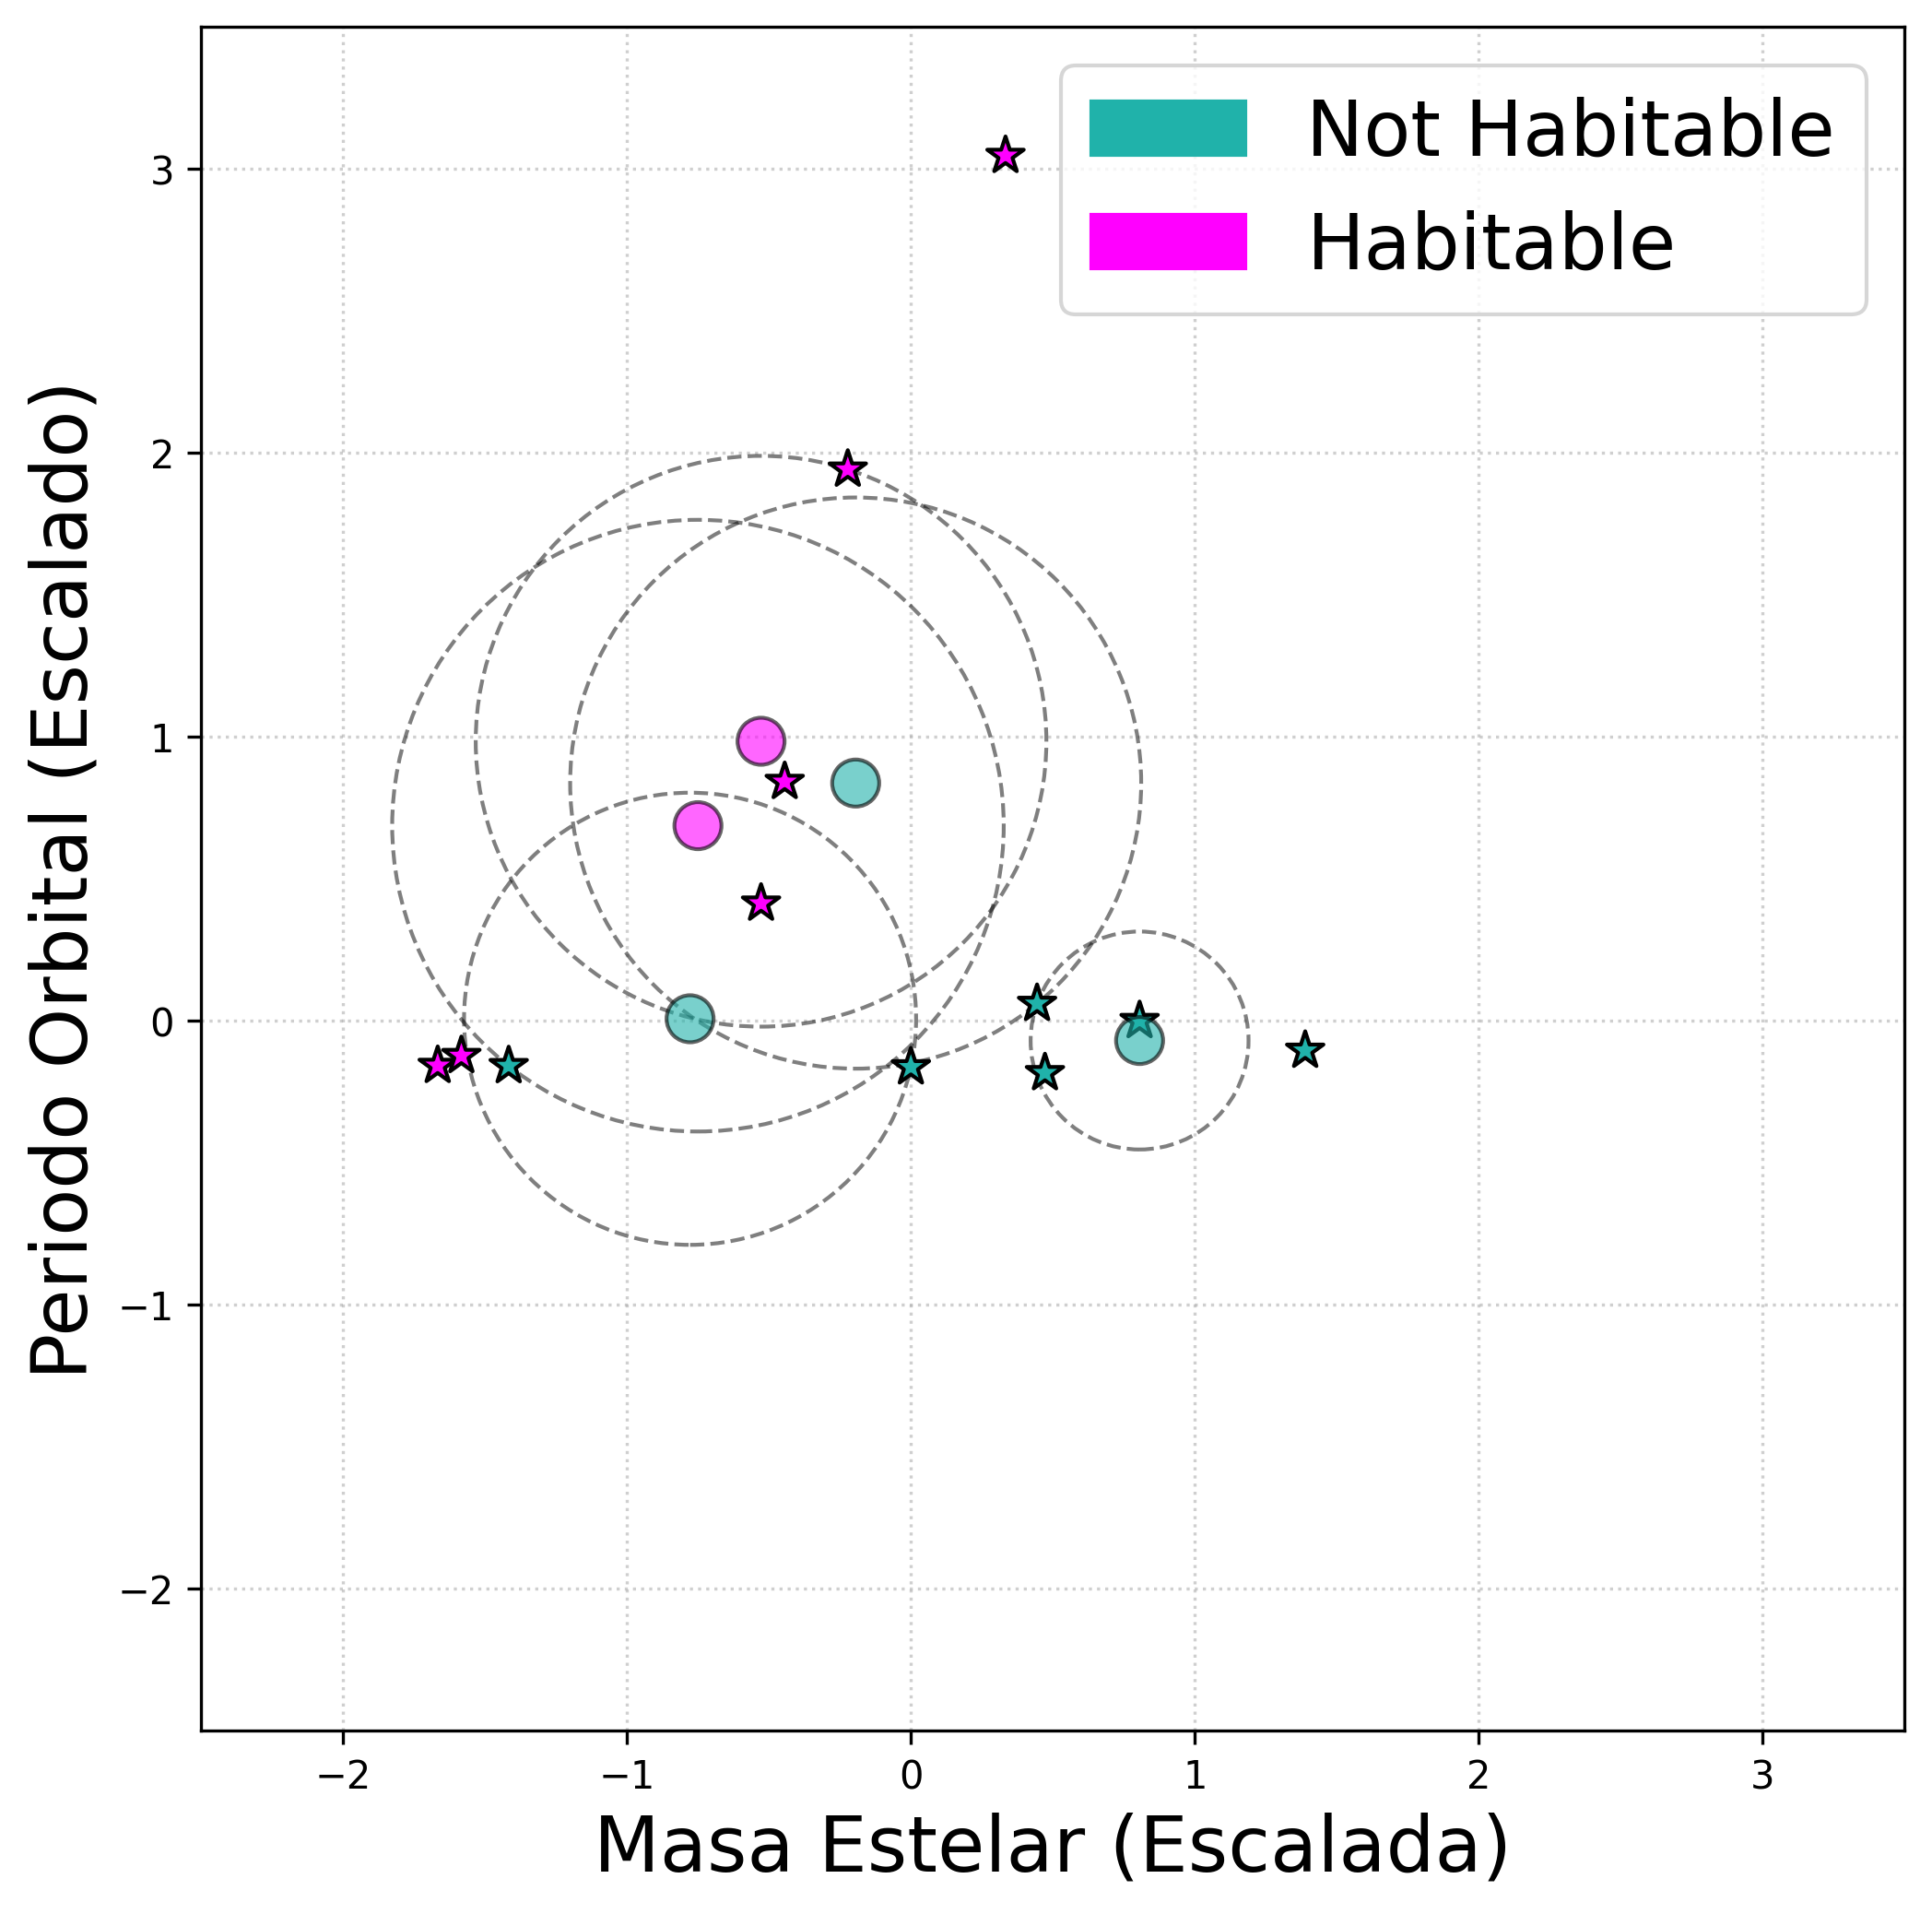

In [106]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
from sklearn.neighbors import KNeighborsClassifier

# 1. Limpiar cualquier gráfico previo
plt.clf()
plt.close('all')

# 2. Re-entrenar modelo 2D rápido para asegurar radios pequeños
model_2d = KNeighborsClassifier(n_neighbors=3)
model_2d.fit(scaledXTrain[:, :2], ytrain)
distances, indices = model_2d.kneighbors(scaledXtest[:, :2])

# 3. Crear figura cuadrada
fig, ax = plt.subplots(figsize=(8, 8))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

# Dibujar puntos
ax.scatter(scaledXTrain[:, 0], scaledXTrain[:, 1], marker='*', facecolor='None',
           c=ytrain, s=100, label='Train', cmap=cmap, edgecolors='k', zorder=3)

ax.scatter(scaledXtest[:, 0], scaledXtest[:, 1], marker='o', facecolor='None',
           c=ytest, s=150, label='Test', cmap=cmap, alpha=0.6, edgecolors='k', zorder=4)

# 4. Dibujar círculos
for i in range(len(scaledXtest)):
    centro = (scaledXtest[i, 0], scaledXtest[i, 1])
    radio = distances[i, 2]
    circle = plt.Circle(centro, radio, lw=1, edgecolor='black', facecolor='none',
                        linestyle='--', alpha=0.5, zorder=2)
    ax.add_artist(circle)

ax.set_xlim(-2.5, 3.5)
ax.set_ylim(-2.5, 3.5)

# Aspecto cuadrado real
ax.set_aspect('equal', adjustable='box')

# 6. Leyendas y estética
bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')
ax.legend(handles=[bluepatch, magentapatch], loc='upper right')

ax.set_xlabel('Masa Estelar (Escalada)')
ax.set_ylabel('Periodo Orbital (Escalado)')
ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

**Repita el proceso de kNN escalado, pero usando todas las caracteristicas, y compare el accuracy**

In [107]:
# 1. Definir el modelo kNN con k=3
model_all_features = neighbors.KNeighborsClassifier(n_neighbors=3)

# 2. Ajustar el modelo usando todas las características ya escaladas
# (Usamos scaledXTrain y scaledXtest que ya vienen del RobustScaler)
model_all_features.fit(scaledXTrain, ytrain)

# 3. Generar predicciones con el set de prueba completo
ypred_all = model_all_features.predict(scaledXtest)

# 4. Calcular Accuracy para comparar
train_acc_all = metrics.accuracy_score(ytrain, model_all_features.predict(scaledXTrain))
test_acc_all = metrics.accuracy_score(ytest, ypred_all)

print("--- COMPARATIVA FINAL DE ACCURACY (kNN) ---")
print(f"Accuracy Entrenamiento (Todas las features): {train_acc_all:.4f}")
print(f"Accuracy Prueba (Todas las features):      {test_acc_all:.4f}")
print("-" * 43)
# comparando
print(f"Diferencia vs Modelo 2D: {test_acc_all - 0.80:.4f}")

--- COMPARATIVA FINAL DE ACCURACY (kNN) ---
Accuracy Entrenamiento (Todas las features): 0.8462
Accuracy Prueba (Todas las features):      0.8000
-------------------------------------------
Diferencia vs Modelo 2D: 0.0000


### Preguntas

- Descubrimos que kNN necesita escalado ¿DT tiene el mismo problema?

No, porque el Árbol solo busca dónde "cortar" cada variable por separado sin compararla con las otras.

- Compare las fortalezas y debilidades de DT y kNN

DT es rápido e interpretable, pero tiende al sobreajuste e inestabilidad ante cambios mínimos en los datos de entrada. kNN es intuitivo y eficaz para fronteras complejas, pero resulta costoso en grandes volúmenes y es sumamente sensible al ruido.

- ¿Qué diferencia conceptual hay entre cómo clasifica un árbol de decisión y cómo clasifica kNN?

kNN clasifica por analogía basándose en la cercanía geométrica, asumiendo que los objetos similares suelen estar agrupados espacialmente. El Árbol de Decisión clasifica por discriminación lógica, creando un flujo de preguntas binarias que dividen los datos sistemáticamente.

- ¿Por qué el accuracy en entrenamiento no basta para evaluar un modelo?

Un accuracy alto en entrenamiento puede ocultar un sobreajuste donde el modelo memoriza el ruido en lugar de aprender patrones reales.

- ¿Por qué kNN requiere escalamiento y un árbol de decisión no necesariamente?

kNN necesita que todas las variables aporten equitativamente al cálculo de la distancia para evitar sesgos por magnitudes diferentes. DT no lo requiere porque evalúa cada característica de forma aislada, buscando el punto de corte sin comparar unidades distintas.

- Si tuvieras que elegir uno de los dos métodos para este dataset pequeño, ¿cuál elegirías y por qué?

Elegiría el Árbol de Decisión por su alta interpretabilidad, permitiendo extraer reglas claras sobre la habitabilidad planetaria. Además, su robustez ante variables irrelevantes lo hace más fiable que kNN en contextos con datos limitados y ruidosos.


### **Desafíos**



1.   Estudiar el efecto del valor de k. Elegir distintos valores de k y graficar k vs accuracy.

El valor de k regula la complejidad del modelo, un valor pequeño genera sobreajuste al ruido, mientras que uno muy grande simplifica demasiado la clasificación.

2.   Explorar efectos de hyperparámetros de un árbol. Elegir 2 hyperparámetros, cambiar los valores y comparar con modelo inicial

Ajustar la profundidad máxima y el mínimo de muestras para dividir permite podar el árbol, evitando que memorice casos aislados del set de entrenamiento.



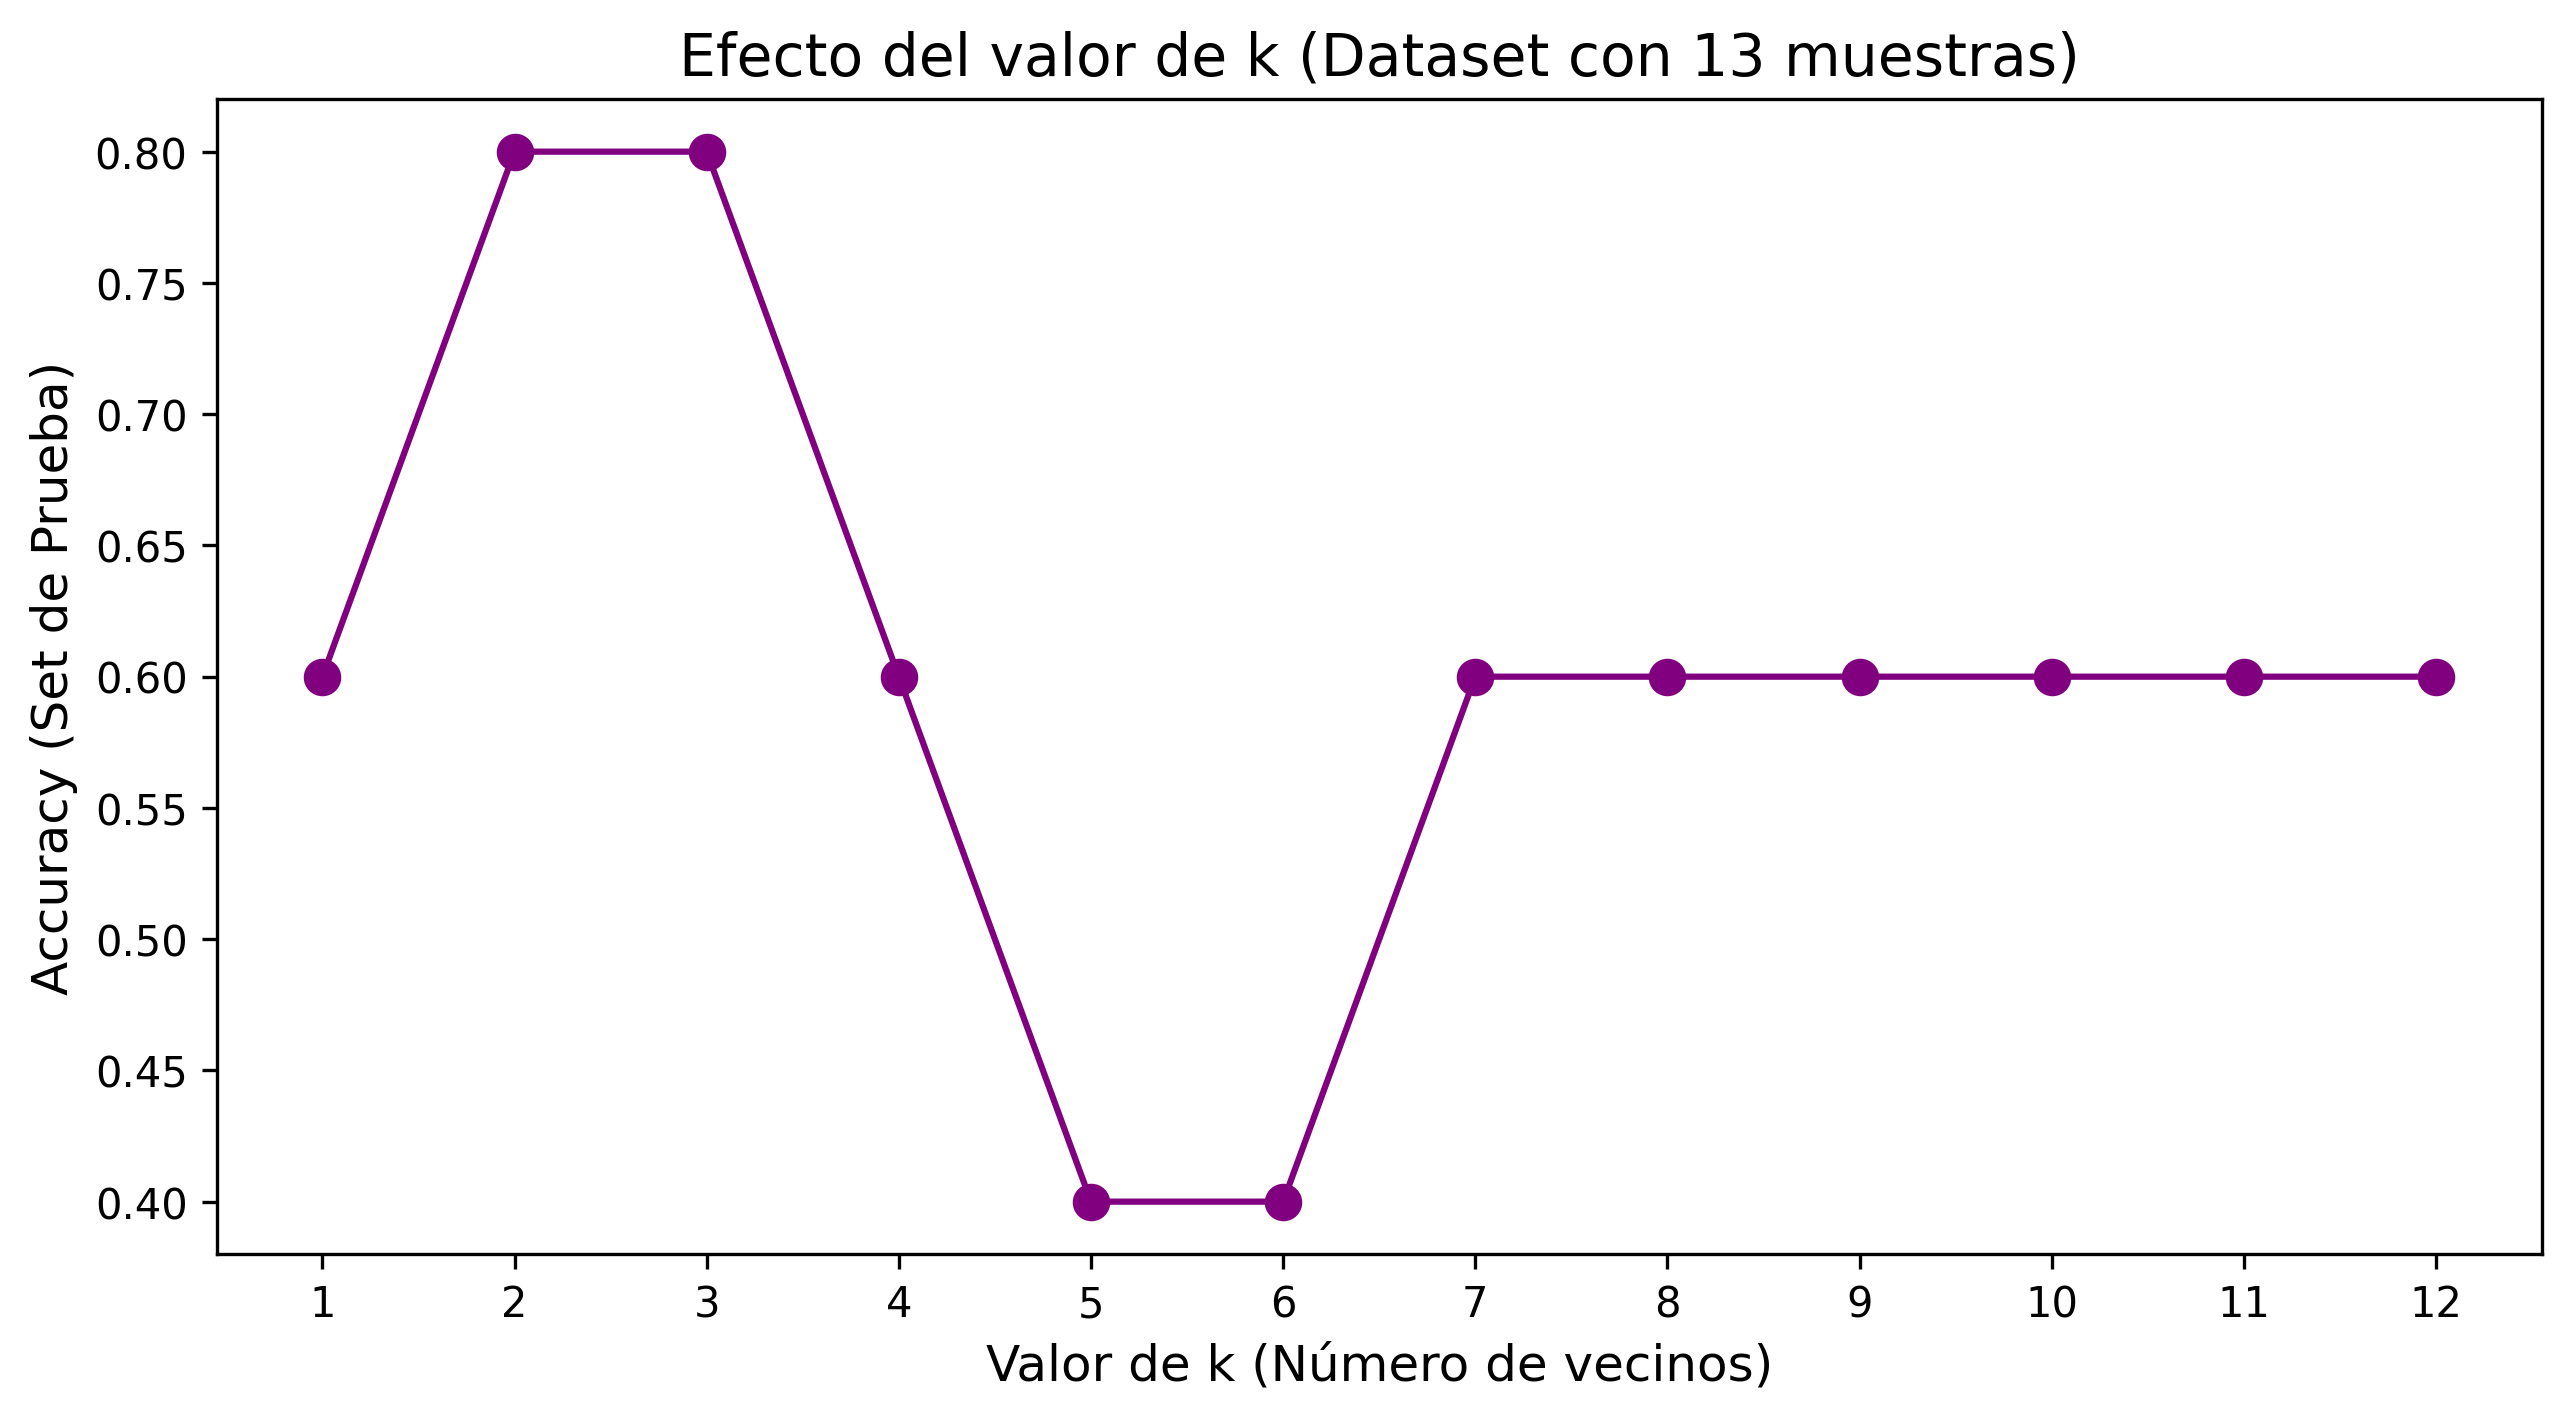

In [110]:
import matplotlib.pyplot as plt
from sklearn import neighbors, metrics

# 1. Calculamos el máximo k posible (n_samples_fit)
max_samples = len(scaledXTrain)
# Usaremos un rango hasta el total de muestras o 20 (lo que sea menor)
k_limit = min(max_samples, 20)
k_range = range(1, k_limit)

scores = []

for k in k_range:
    # Entrenamos con k actual
    knn_model = neighbors.KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(scaledXTrain, ytrain)

    # Predecimos y guardamos el accuracy de prueba
    ypred = knn_model.predict(scaledXtest)
    scores.append(metrics.accuracy_score(ytest, ypred))

# 2. Graficar k vs Accuracy
plt.figure(figsize=(10, 5))
plt.plot(list(k_range), scores, marker='o', linestyle='-', color='purple', markersize=8)
plt.title(f'Efecto del valor de k (Dataset con {max_samples} muestras)', fontsize=14)
plt.xlabel('Valor de k (Número de vecinos)', fontsize=12)
plt.ylabel('Accuracy (Set de Prueba)', fontsize=12)
plt.xticks(list(k_range))
plt.show()

Accuracy del modelo ajustado (Test): 0.8000


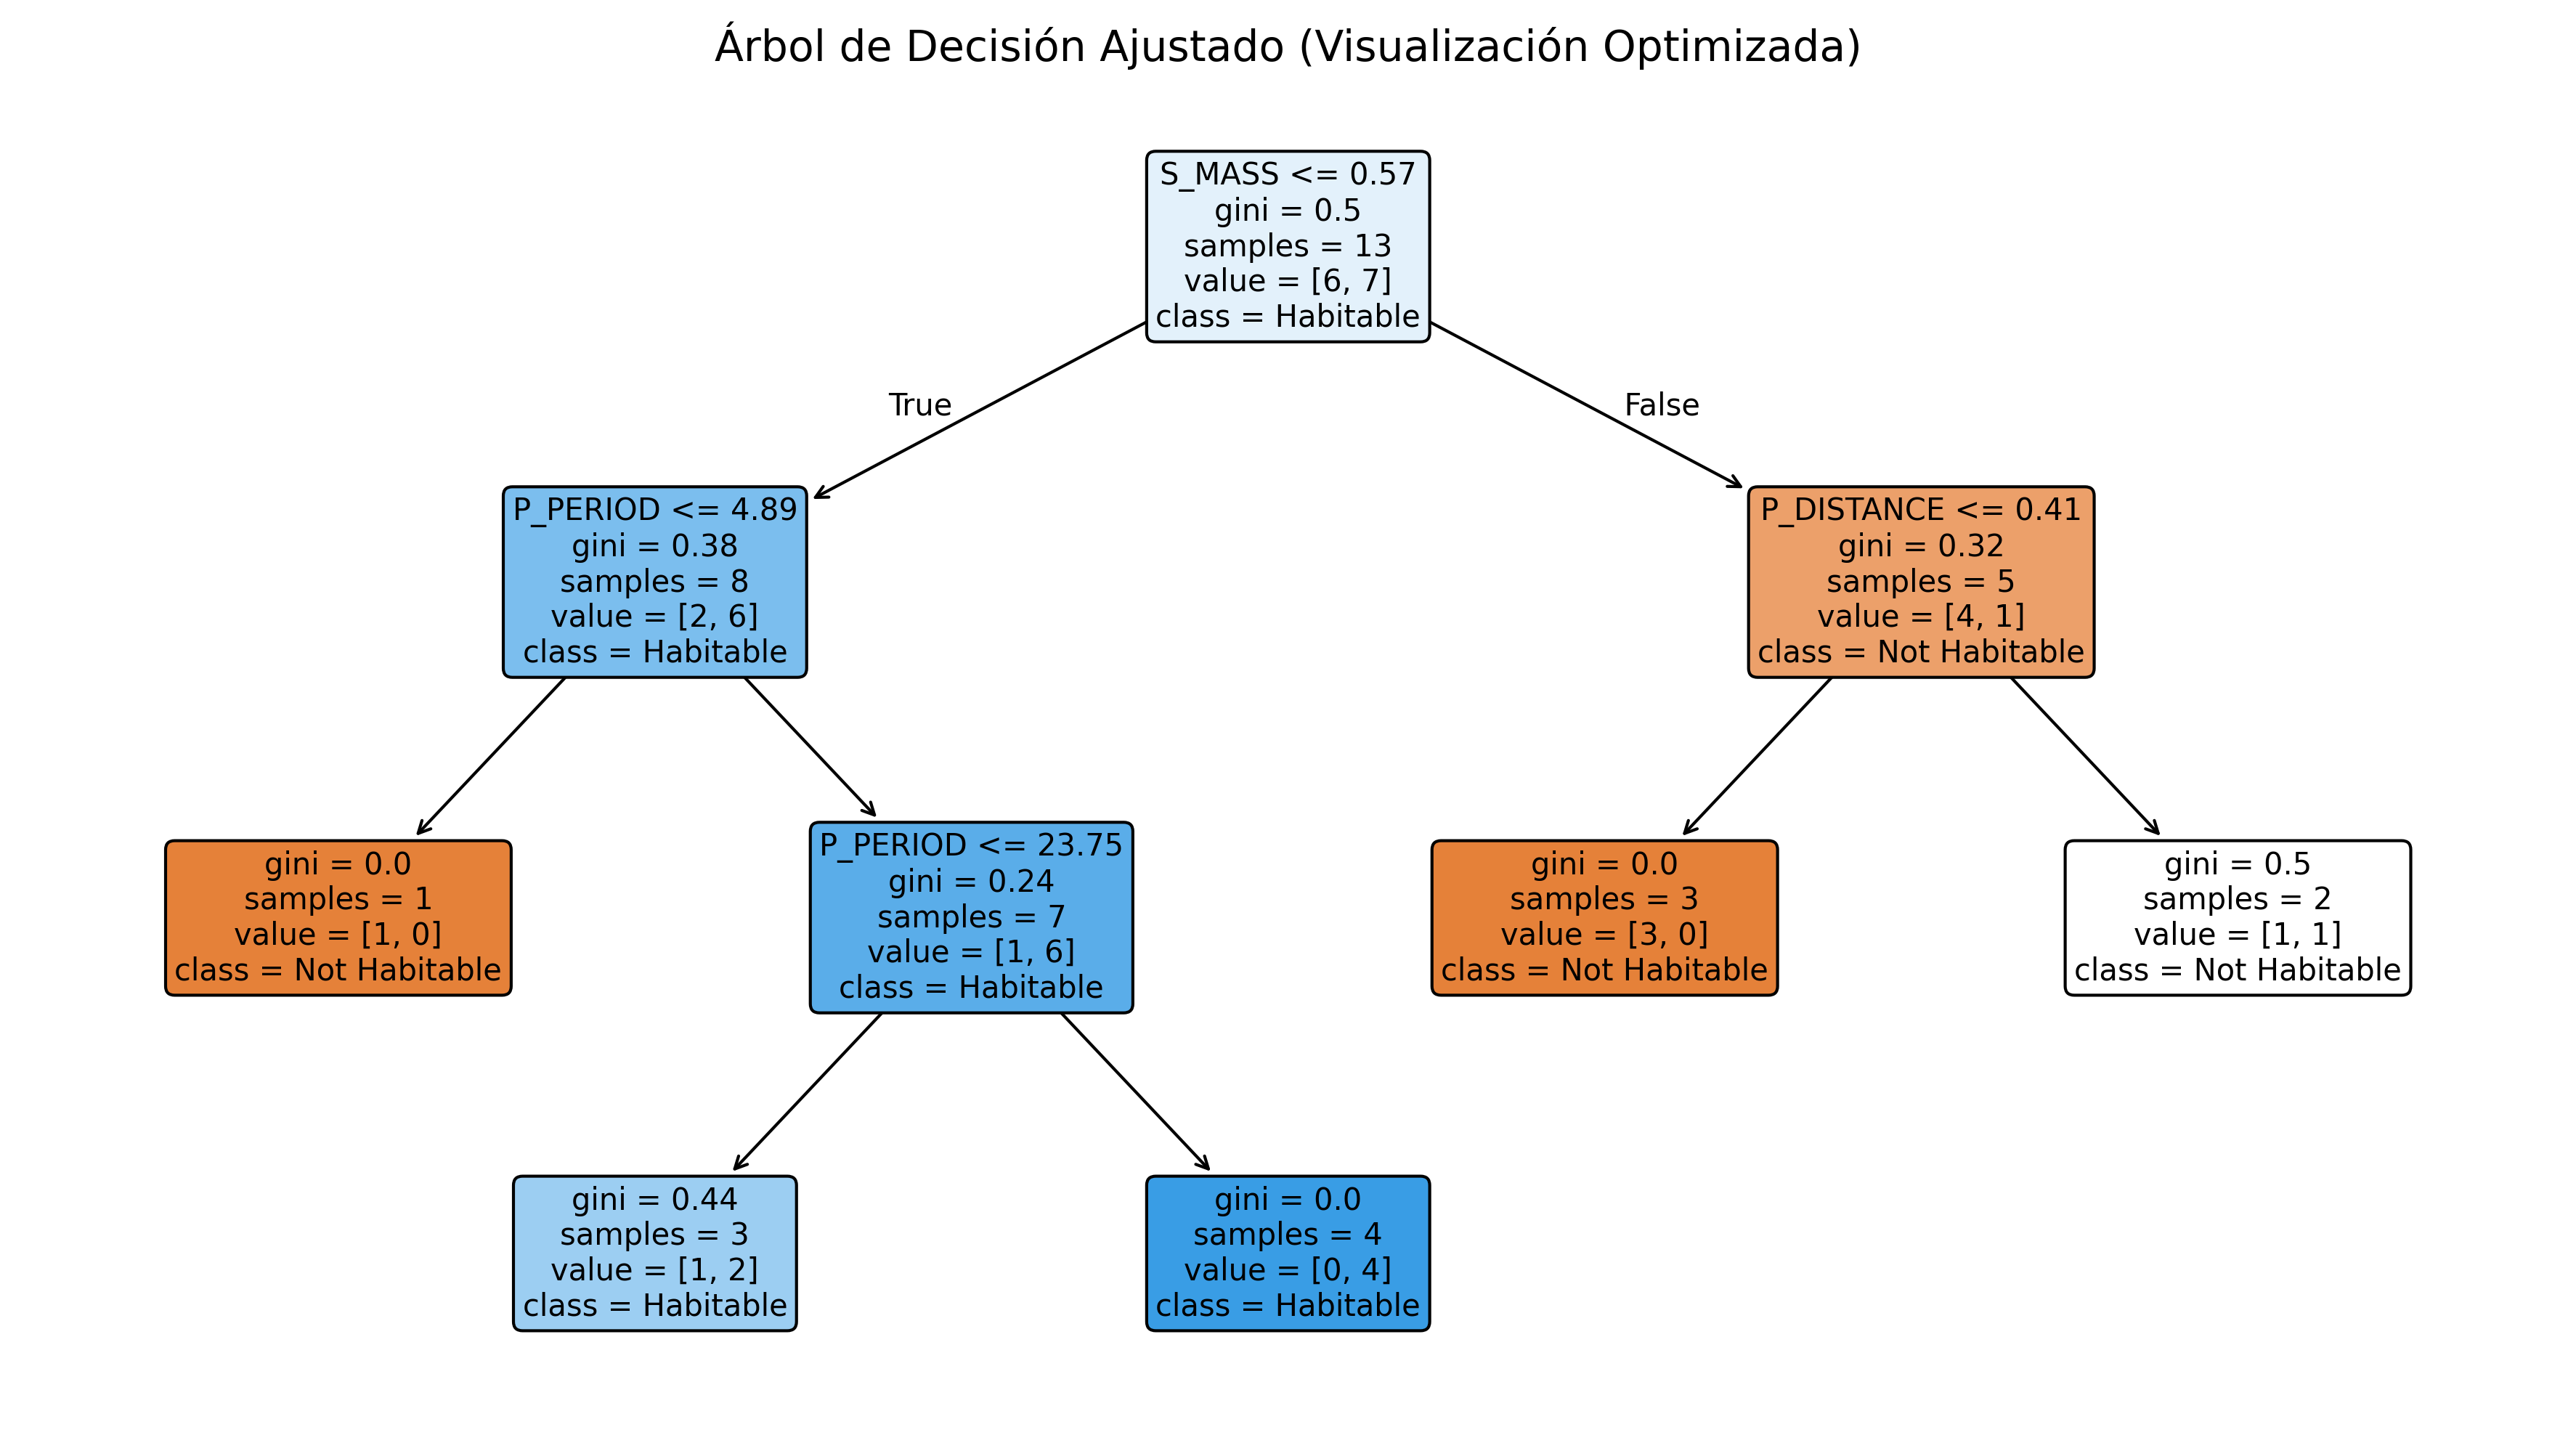

In [113]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics

# 1. Definir y entrenar el modelo ajustado
model_tuned = DecisionTreeClassifier(max_depth=3, min_samples_split=4, random_state=3)
model_tuned.fit(Xtrain2, ytrain2)

# 2. Calcular scores
acc_tuned_test = metrics.accuracy_score(ytest2, model_tuned.predict(Xtest2))
print(f"Accuracy del modelo ajustado (Test): {acc_tuned_test:.4f}")

plt.figure(figsize=(15, 8))

plot_tree(model_tuned,
          feature_names=Xtrain2.columns,
          class_names=['Not Habitable', 'Habitable'],
          filled=True,
          rounded=True,
          fontsize=10,
          precision=2)

plt.title("Árbol de Decisión Ajustado (Visualización Optimizada)", fontsize=14)
plt.show()